# Notebook 02 — Factor Effects

This notebook analyzes the marginal and interaction effects of key pipeline components on predictive performance.
It is designed to operate on top of the outputs exported by **Notebook 01**, with special emphasis on **fairly comparable metrics across validation strategies**, including the leave-one-out (LOO) configuration after confusion-matrix-based reconstruction.

The notebook focuses primarily on classical metrics that remain comparable across validation regimes: **accuracy**, **precision**, **recall**, **F1-score**, **balanced accuracy**, and **MCC**. Metrics that require probabilistic predictions (ROC-AUC, PR-AUC, and Brier score) are only used in restricted, non-LOO analyses when explicitly indicated.

In [1]:
from __future__ import annotations

import math
from pathlib import Path

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(style="whitegrid", context="talk")
pd.set_option("display.max_columns", 200)
pd.set_option("display.max_rows", 200)

In [2]:
def find_repo_root(start: Path | None = None, repo_name: str = "hypercholesterolemia_classifiers") -> Path:
    candidates = []
    if start is not None:
        candidates.append(start.resolve())
    candidates.extend([
        Path.cwd().resolve(),
        Path("/home/david/Desktop/colabs/serra_ramon/hypercholesterolemia_classifiers"),
    ])
    for candidate in candidates:
        if candidate.name == repo_name and candidate.exists():
            return candidate
        for parent in [candidate, *candidate.parents]:
            if parent.name == repo_name and parent.exists():
                return parent
    # Fallback for this execution environment
    fallback = Path("/mnt/data/hyperchol_repo")
    if fallback.exists():
        return fallback
    raise FileNotFoundError("Could not locate the repository root.")

REPO_ROOT = find_repo_root()
ANALYSIS_DIR = REPO_ROOT / "notebooks" / "modelling" / "analysis_tables"
FIGURES_DIR = REPO_ROOT / "notebooks" / "modelling" / "analysis_figures" / "02_factor_effects"

ANALYSIS_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

def save_figure(fig: plt.Figure, filename: str, dpi: int = 300) -> Path:
    out_path = FIGURES_DIR / filename
    fig.savefig(out_path, dpi=dpi, bbox_inches="tight")
    return out_path

print("Repository root:", REPO_ROOT)
print("Analysis tables:", ANALYSIS_DIR)
print("Figures directory:", FIGURES_DIR)

Repository root: /home/david/Desktop/colabs/serra_ramon/hypercholesterolemia_classifiers
Analysis tables: /home/david/Desktop/colabs/serra_ramon/hypercholesterolemia_classifiers/notebooks/modelling/analysis_tables
Figures directory: /home/david/Desktop/colabs/serra_ramon/hypercholesterolemia_classifiers/notebooks/modelling/analysis_figures/02_factor_effects


## Inputs

The notebook expects the exports generated by Notebook 01:

- `results_seed_level.csv`
- `results_config_level.csv`

The first file is the core input for marginal analyses, interaction analyses, and factor-level comparisons. The second file is used for configuration-level summaries and top-ranked combinations.

In [3]:
seed_level_path = ANALYSIS_DIR / "results_seed_level.csv"
config_level_path = ANALYSIS_DIR / "results_config_level.csv"

if not seed_level_path.exists():
    raise FileNotFoundError(
        f"Missing {seed_level_path}. Run Notebook 01 first so the consolidated tables are exported."
    )

results_seed_level = pd.read_csv(seed_level_path)
results_config_level = pd.read_csv(config_level_path) if config_level_path.exists() else None

print("results_seed_level:", results_seed_level.shape)
if results_config_level is not None:
    print("results_config_level:", results_config_level.shape)

results_seed_level.head()

results_seed_level: (2000588, 34)
results_config_level: (193305, 40)


,dataset_variant,config_name,run_id,combo_id,val_strategy,seed,threshold,model_key,model_class,model_params,imputer,scaler,pca,pca_params,resampling,resampling_params,n_evaluation_units,n_train,n_test,pos_rate_test,tn,fp,fn,tp,roc_auc,pr_auc,mcc,brier,accuracy,balanced_accuracy,precision,recall,f1,loo_metric_source
0,IMPUTED,config_kfold,20260202_032849,1,kfold,4.781633e+08,0.5,LogisticRegression,LogisticRegression,"{""C"": 0.1, ""class_weight"": null, ""penalty"": ""l2""}",none,none,off,{},none,{},5,128.0,32.0,0.275,106,10,24,20,0.803034,0.659453,0.411356,0.151723,0.78750,0.681884,0.658889,0.450000,0.507512,reported_fold_mean
1,IMPUTED,config_kfold,20260202_032849,2,kfold,1.122457e+09,0.5,LogisticRegression,LogisticRegression,"{""C"": 0.1, ""class_weight"": null, ""penalty"": ""l2""}",none,none,off,{},none,{},5,128.0,32.0,0.275,107,9,25,19,0.820018,0.680020,0.423810,0.148044,0.78750,0.676510,0.707302,0.430556,0.518162,reported_fold_mean
2,IMPUTED,config_kfold,20260202_032849,3,kfold,1.988882e+08,0.5,LogisticRegression,LogisticRegression,"{""C"": 0.1, ""class_weight"": null, ""penalty"": ""l2""}",none,none,off,{},none,{},5,128.0,32.0,0.275,107,9,23,21,0.825377,0.663983,0.462220,0.143389,0.80000,0.700302,0.732698,0.477778,0.545664,reported_fold_mean
3,IMPUTED,config_kfold,20260202_032849,4,kfold,1.648071e+09,0.5,LogisticRegression,LogisticRegression,"{""C"": 0.1, ""class_weight"": null, ""penalty"": ""l2""}",none,none,off,{},none,{},5,128.0,32.0,0.275,106,10,21,23,0.814538,0.679425,0.481473,0.148196,0.80625,0.717995,0.697619,0.522222,0.595462,reported_fold_mean
4,IMPUTED,config_kfold,20260202_032849,5,kfold,2.013804e+09,0.5,LogisticRegression,LogisticRegression,"{""C"": 0.1, ""class_weight"": null, ""penalty"": ""l2""}",none,none,off,{},none,{},5,128.0,32.0,0.275,103,13,26,18,0.801283,0.652545,0.335151,0.154048,0.75625,0.649577,0.586508,0.411111,0.457560,reported_fold_mean


In [4]:
CLASSICAL_METRICS = ["accuracy", "precision", "recall", "f1", "balanced_accuracy", "mcc"]
PROB_METRICS = ["roc_auc", "pr_auc", "brier"]
FACTOR_COLUMNS = [
    "dataset_variant",
    "config_name",
    "val_strategy",
    "model_key",
    "model_class",
    "imputer",
    "scaler",
    "pca",
    "resampling",
]

present_factor_columns = [c for c in FACTOR_COLUMNS if c in results_seed_level.columns]
present_classical_metrics = [c for c in CLASSICAL_METRICS if c in results_seed_level.columns]
present_prob_metrics = [c for c in PROB_METRICS if c in results_seed_level.columns]

print("Available factor columns:", present_factor_columns)
print("Available classical metrics:", present_classical_metrics)
print("Available probabilistic metrics:", present_prob_metrics)

Available factor columns: ['dataset_variant', 'config_name', 'val_strategy', 'model_key', 'model_class', 'imputer', 'scaler', 'pca', 'resampling']
Available classical metrics: ['accuracy', 'precision', 'recall', 'f1', 'balanced_accuracy', 'mcc']
Available probabilistic metrics: ['roc_auc', 'pr_auc', 'brier']


In [5]:
# Basic cleaning and normalization of labels for plotting/reporting
df = results_seed_level.copy()

for col in ["dataset_variant", "config_name", "val_strategy", "model_key", "model_class", "imputer", "scaler", "pca", "resampling"]:
    if col in df.columns:
        df[col] = df[col].fillna("missing").astype(str)

if "pca" in df.columns:
    df["pca"] = (
        df["pca"]
        .replace({"None": "none", "nan": "none", "False": "none"})
        .astype(str)
    )

if "resampling" in df.columns:
    df["resampling"] = (
        df["resampling"]
        .replace({"None": "none", "nan": "none"})
        .astype(str)
    )

if "scaler" in df.columns:
    df["scaler"] = (
        df["scaler"]
        .replace({"None": "none", "nan": "none"})
        .astype(str)
    )

if "dataset_variant" in df.columns:
    dataset_order = sorted(df["dataset_variant"].dropna().unique().tolist())
else:
    dataset_order = None

if "config_name" in df.columns:
    config_order = sorted(df["config_name"].dropna().unique().tolist())
else:
    config_order = None

df.head()

,dataset_variant,config_name,run_id,combo_id,val_strategy,seed,threshold,model_key,model_class,model_params,imputer,scaler,pca,pca_params,resampling,resampling_params,n_evaluation_units,n_train,n_test,pos_rate_test,tn,fp,fn,tp,roc_auc,pr_auc,mcc,brier,accuracy,balanced_accuracy,precision,recall,f1,loo_metric_source
0,IMPUTED,config_kfold,20260202_032849,1,kfold,4.781633e+08,0.5,LogisticRegression,LogisticRegression,"{""C"": 0.1, ""class_weight"": null, ""penalty"": ""l2""}",none,none,off,{},none,{},5,128.0,32.0,0.275,106,10,24,20,0.803034,0.659453,0.411356,0.151723,0.78750,0.681884,0.658889,0.450000,0.507512,reported_fold_mean
1,IMPUTED,config_kfold,20260202_032849,2,kfold,1.122457e+09,0.5,LogisticRegression,LogisticRegression,"{""C"": 0.1, ""class_weight"": null, ""penalty"": ""l2""}",none,none,off,{},none,{},5,128.0,32.0,0.275,107,9,25,19,0.820018,0.680020,0.423810,0.148044,0.78750,0.676510,0.707302,0.430556,0.518162,reported_fold_mean
2,IMPUTED,config_kfold,20260202_032849,3,kfold,1.988882e+08,0.5,LogisticRegression,LogisticRegression,"{""C"": 0.1, ""class_weight"": null, ""penalty"": ""l2""}",none,none,off,{},none,{},5,128.0,32.0,0.275,107,9,23,21,0.825377,0.663983,0.462220,0.143389,0.80000,0.700302,0.732698,0.477778,0.545664,reported_fold_mean
3,IMPUTED,config_kfold,20260202_032849,4,kfold,1.648071e+09,0.5,LogisticRegression,LogisticRegression,"{""C"": 0.1, ""class_weight"": null, ""penalty"": ""l2""}",none,none,off,{},none,{},5,128.0,32.0,0.275,106,10,21,23,0.814538,0.679425,0.481473,0.148196,0.80625,0.717995,0.697619,0.522222,0.595462,reported_fold_mean
4,IMPUTED,config_kfold,20260202_032849,5,kfold,2.013804e+09,0.5,LogisticRegression,LogisticRegression,"{""C"": 0.1, ""class_weight"": null, ""penalty"": ""l2""}",none,none,off,{},none,{},5,128.0,32.0,0.275,103,13,26,18,0.801283,0.652545,0.335151,0.154048,0.75625,0.649577,0.586508,0.411111,0.457560,reported_fold_mean


## Coverage and sanity checks

Before comparing factor effects, it is useful to confirm that the seed-level table contains sufficient coverage across metrics and factor levels.

In [6]:
coverage_by_config = (
    df.groupby("config_name")[present_classical_metrics + present_prob_metrics]
    .agg(lambda s: s.notna().sum())
    .sort_index()
)

coverage_by_config

,accuracy,precision,recall,f1,balanced_accuracy,mcc,roc_auc,pr_auc,brier
config_name,,,,,,,,,
config_kfold,944152,944152,944152,944152,944152,944152,944152,944152,944152
config_loo,39789,39610,39789,39789,39789,39610,0,0,0
config_random80,504927,504927,504927,504927,504927,504927,504927,504927,504927
config_strat80,511720,511720,511720,511720,511720,511720,511720,511720,511720


In [7]:
factor_cardinality = pd.DataFrame({
    "factor": present_factor_columns,
    "n_unique_levels": [df[col].nunique(dropna=False) for col in present_factor_columns],
})
factor_cardinality

,factor,n_unique_levels
0,dataset_variant,2
1,config_name,4
2,val_strategy,4
3,model_key,7
4,model_class,7
5,imputer,2
6,scaler,4
7,pca,2
8,resampling,4


## Global factor summaries

This section estimates the marginal effect of each major factor on the main performance metrics. The objective is not yet to identify the single best configuration, but rather to understand which modeling decisions tend to improve or worsen performance across the explored design space.

In [8]:
def summarize_factor_effects(
    data: pd.DataFrame,
    factor: str,
    metrics: list[str],
    min_count: int = 1,
) -> pd.DataFrame:
    agg_dict = {}
    for metric in metrics:
        agg_dict[f"{metric}_mean"] = (metric, "mean")
        agg_dict[f"{metric}_std"] = (metric, "std")
        agg_dict[f"{metric}_median"] = (metric, "median")
        agg_dict[f"{metric}_count"] = (metric, "count")

    summary = (
        data.groupby(factor, dropna=False)
        .agg(**agg_dict)
        .reset_index()
    )

    count_cols = [f"{metric}_count" for metric in metrics if f"{metric}_count" in summary.columns]
    if count_cols:
        keep_mask = summary[count_cols].max(axis=1) >= min_count
        summary = summary.loc[keep_mask].copy()

    return summary.sort_values(by=[f"{metrics[-1]}_mean"], ascending=False)

factor_summaries = {}
for factor in ["dataset_variant", "config_name", "val_strategy", "model_key", "scaler", "resampling", "pca"]:
    if factor in df.columns:
        factor_summaries[factor] = summarize_factor_effects(df, factor, present_classical_metrics)

for factor, summary in factor_summaries.items():
    print("\n", "=" * 100)
    print(f"Factor: {factor}")
    display(summary)


Factor: dataset_variant


,dataset_variant,accuracy_mean,accuracy_std,accuracy_median,accuracy_count,precision_mean,precision_std,precision_median,precision_count,recall_mean,recall_std,recall_median,recall_count,f1_mean,f1_std,f1_median,f1_count,balanced_accuracy_mean,balanced_accuracy_std,balanced_accuracy_median,balanced_accuracy_count,mcc_mean,mcc_std,mcc_median,mcc_count
0,IMPUTED,0.723831,0.075373,0.725000,984040,0.512097,0.128823,0.500000,983978,0.668783,0.181211,0.670000,984040,0.557113,0.117177,0.567772,984040,0.706959,0.078994,0.708333,984040,0.393629,0.144827,0.394815,983978
1,STRICT,0.717500,0.074873,0.730575,1016548,0.524315,0.128177,0.528485,1016431,0.661283,0.175924,0.666667,1016548,0.559780,0.112826,0.571893,1016548,0.701852,0.072891,0.706349,1016548,0.389765,0.135976,0.400066,1016431



Factor: config_name


,config_name,accuracy_mean,accuracy_std,accuracy_median,accuracy_count,precision_mean,precision_std,precision_median,precision_count,recall_mean,recall_std,recall_median,recall_count,f1_mean,f1_std,f1_median,f1_count,balanced_accuracy_mean,balanced_accuracy_std,balanced_accuracy_median,balanced_accuracy_count,mcc_mean,mcc_std,mcc_median,mcc_count
3,config_strat80,0.719945,0.089959,0.718750,511720,0.539933,0.154843,0.500000,511720,0.658319,0.200227,0.666667,511720,0.570809,0.131556,0.583333,511720,0.701910,0.091174,0.702899,511720,0.395422,0.174881,0.407550,511720
0,config_kfold,0.723134,0.050569,0.730115,944152,0.524351,0.085993,0.525653,944152,0.660792,0.145949,0.680000,944152,0.560954,0.087196,0.572051,944152,0.704195,0.052439,0.707594,944152,0.394653,0.093612,0.401234,944152
1,config_loo,0.720233,0.050594,0.725000,39789,0.511672,0.072495,0.508475,39610,0.661476,0.147522,0.681818,39789,0.562873,0.084140,0.573913,39789,0.702246,0.054652,0.705975,39789,0.384025,0.090927,0.388371,39610
2,config_random80,0.716610,0.095835,0.718750,504927,0.485602,0.159397,0.500000,504927,0.679805,0.209492,0.700000,504927,0.540965,0.140021,0.555556,504927,0.707333,0.095217,0.710227,504927,0.382871,0.173111,0.382971,504927



Factor: val_strategy


...

,scaler,accuracy_mean,accuracy_std,accuracy_median,accuracy_count,precision_mean,precision_std,precision_median,precision_count,recall_mean,recall_std,recall_median,recall_count,f1_mean,f1_std,f1_median,f1_count,balanced_accuracy_mean,balanced_accuracy_std,balanced_accuracy_median,balanced_accuracy_count,mcc_mean,mcc_std,mcc_median,mcc_count
3,standard,0.729688,0.066049,0.733333,608312,0.532591,0.114772,0.528137,608312,0.673362,0.161109,0.666667,608312,0.572409,0.097819,0.576084,608312,0.713264,0.070645,0.712560,608312,0.408353,0.129724,0.408187,608312
1,none,0.726970,0.066469,0.733333,176435,0.534285,0.117663,0.529762,176435,0.656631,0.145889,0.666667,176435,0.565496,0.087547,0.571429,176435,0.706188,0.061818,0.707727,176435,0.398654,0.116833,0.403021,176435
2,robust,0.719549,0.072117,0.725000,608167,0.517735,0.123692,0.508690,608166,0.652613,0.171815,0.666667,608167,0.554180,0.109451,0.560297,608167,0.699899,0.077377,0.701263,608167,0.383606,0.143789,0.387273,608166
0,maxabs,0.710750,0.086967,0.720476,607674,0.499930,0.146109,0.500000,607496,0.671364,0.207374,0.695000,607674,0.546764,0.139204,0.571429,607674,0.699393,0.082412,0.706703,607674,0.380994,0.151448,0.394454,607496



Factor: resampling


,resampling,accuracy_mean,accuracy_std,accuracy_median,accuracy_count,precision_mean,precision_std,precision_median,precision_count,recall_mean,recall_std,recall_median,recall_count,f1_mean,f1_std,f1_median,f1_count,balanced_accuracy_mean,balanced_accuracy_std,balanced_accuracy_median,balanced_accuracy_count,mcc_mean,mcc_std,mcc_median,mcc_count
3,undersample,0.721273,0.075229,0.729524,363746,0.512187,0.118569,0.517659,363716,0.694368,0.159467,0.700000,363746,0.572769,0.112353,0.587647,363746,0.713926,0.077533,0.720350,363746,0.402283,0.145041,0.413518,363716
1,smote,0.731497,0.067434,0.733333,727483,0.527891,0.122376,0.533333,727460,0.652836,0.156408,0.661111,727483,0.565782,0.111335,0.571825,727483,0.708091,0.075058,0.709452,727483,0.398762,0.141646,0.405580,727460
2,smoteenn,0.699920,0.081301,0.706250,727482,0.492325,0.110107,0.496905,727476,0.718756,0.160128,0.736111,727482,0.564987,0.099932,0.571429,727482,0.706668,0.072691,0.707630,727482,0.387088,0.132605,0.387830,727476
0,none,0.758538,0.051076,0.762500,181877,0.596168,0.190600,0.600000,181757,0.439597,0.186688,0.435000,181877,0.474540,0.151162,0.493761,181877,0.661116,0.075547,0.660000,181877,0.360336,0.150735,0.374631,181757



Factor: pca


,pca,accuracy_mean,accuracy_std,accuracy_median,accuracy_count,precision_mean,precision_std,precision_median,precision_count,recall_mean,recall_std,recall_median,recall_count,f1_mean,f1_std,f1_median,f1_count,balanced_accuracy_mean,balanced_accuracy_std,balanced_accuracy_median,balanced_accuracy_count,mcc_mean,mcc_std,mcc_median,mcc_count
0,off,0.728426,0.068124,0.733333,705226,0.535293,0.121556,0.533333,705201,0.646122,0.152941,0.661111,705226,0.561534,0.094958,0.571429,705226,0.703989,0.064457,0.706349,705226,0.396014,0.121685,0.400629,705201
1,on,0.716361,0.078438,0.722989,1295362,0.509056,0.131419,0.503030,1295208,0.675235,0.190320,0.692308,1295362,0.556799,0.124523,0.571429,1295362,0.704568,0.081596,0.708333,1295362,0.389298,0.149574,0.395794,1295208


In [9]:
def plot_factor_boxplots(
    data: pd.DataFrame,
    factor: str,
    metrics: list[str],
    hue: str | None = None,
    order: list[str] | None = None,
    figsize: tuple[int, int] = (20, 12),
):
    ncols = 2
    nrows = math.ceil(len(metrics) / ncols)
    fig, axes = plt.subplots(nrows, ncols, figsize=figsize)
    axes = np.array(axes).reshape(-1)

    handles = labels = None
    for ax, metric in zip(axes, metrics):
        plot_df = data.loc[data[metric].notna()].copy()
        sns.boxplot(
            data=plot_df,
            x=factor,
            y=metric,
            hue=hue,
            order=order,
            ax=ax,
            showfliers=False,
        )
        ax.set_title(f"{metric} by {factor}")
        ax.tick_params(axis="x", rotation=35)
        ax.grid(alpha=0.2)
        if hue is not None:
            handles, labels = ax.get_legend_handles_labels()
            if ax.legend_ is not None:
                ax.legend_.remove()

    for ax in axes[len(metrics):]:
        ax.axis("off")

    if hue is not None and handles is not None:
        fig.legend(handles, labels, loc="upper center", ncol=min(len(labels), 4), frameon=False)

    plt.tight_layout(rect=[0, 0, 1, 0.96] if hue is not None else None)
    return fig

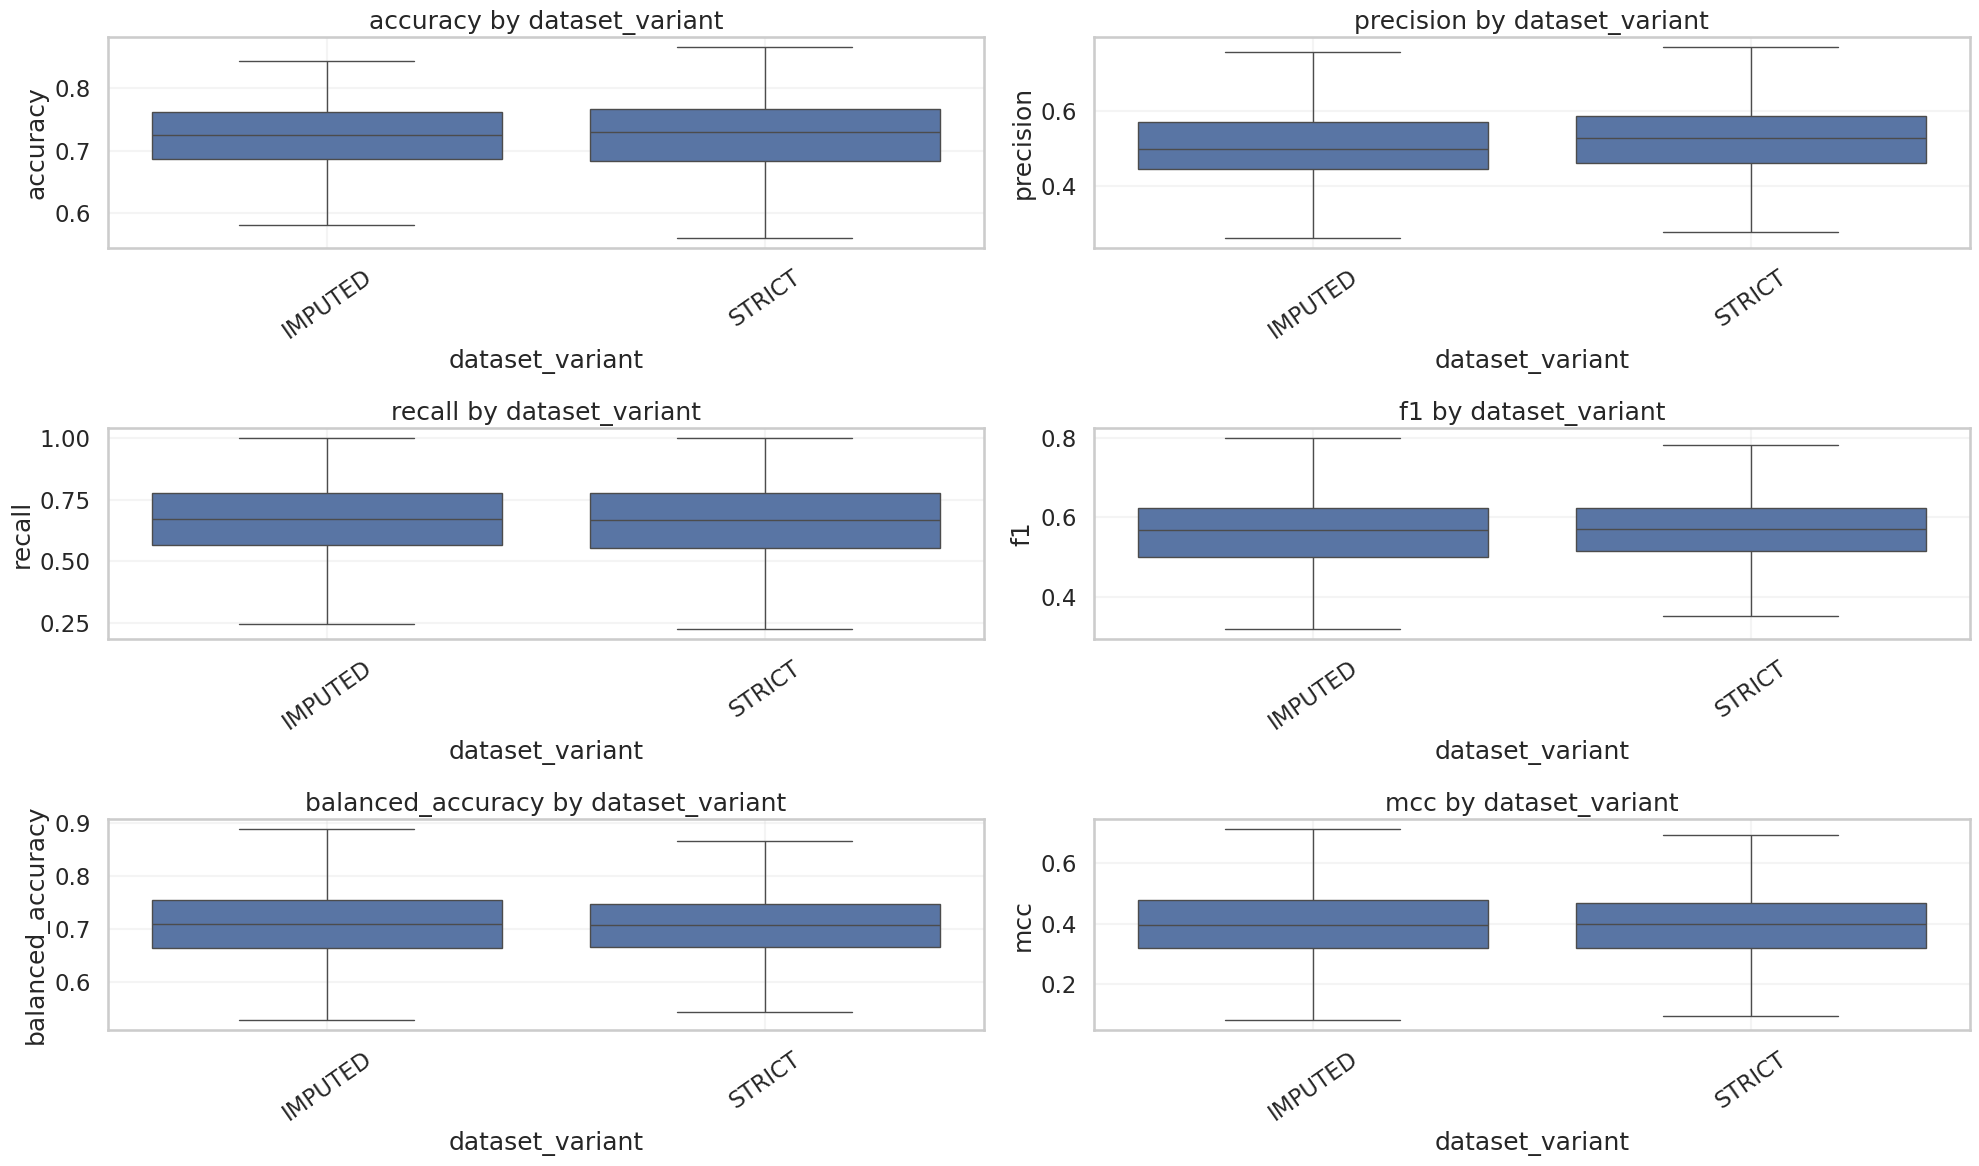

In [10]:
# Dataset variant effect
if "dataset_variant" in df.columns:
    fig = plot_factor_boxplots(
        df,
        factor="dataset_variant",
        metrics=present_classical_metrics,
        order=dataset_order,
        figsize=(20, 12),
    )
    save_figure(fig, "dataset_variant_effect_boxplots.png")
    plt.show()

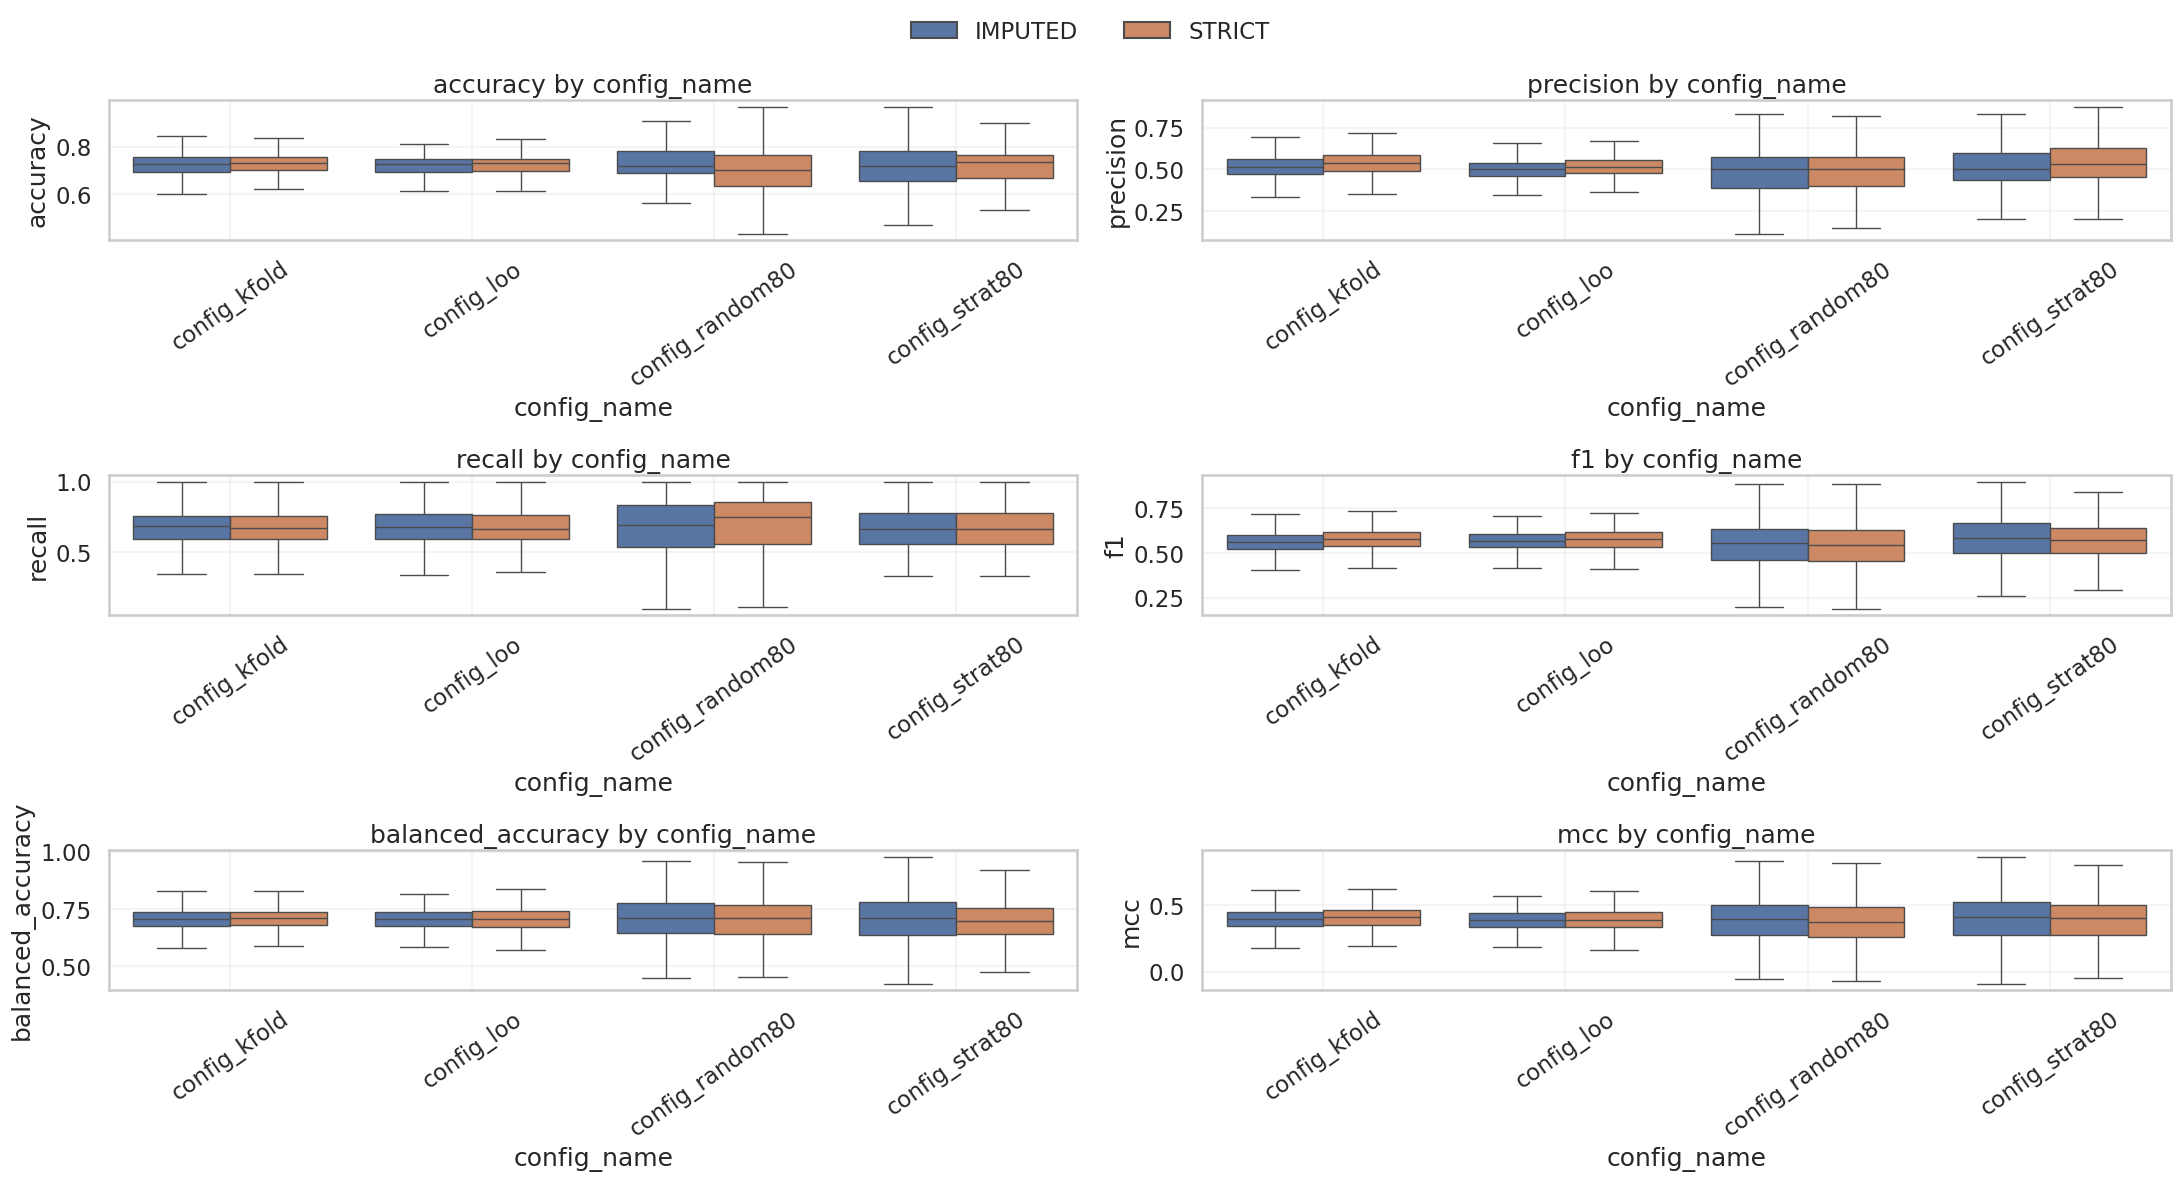

In [11]:
# Validation strategy effect
if "config_name" in df.columns and "dataset_variant" in df.columns:
    fig = plot_factor_boxplots(
        df,
        factor="config_name",
        metrics=present_classical_metrics,
        hue="dataset_variant",
        order=config_order,
        figsize=(22, 12),
    )
    save_figure(fig, "config_name_effect_boxplots.png")
    plt.show()

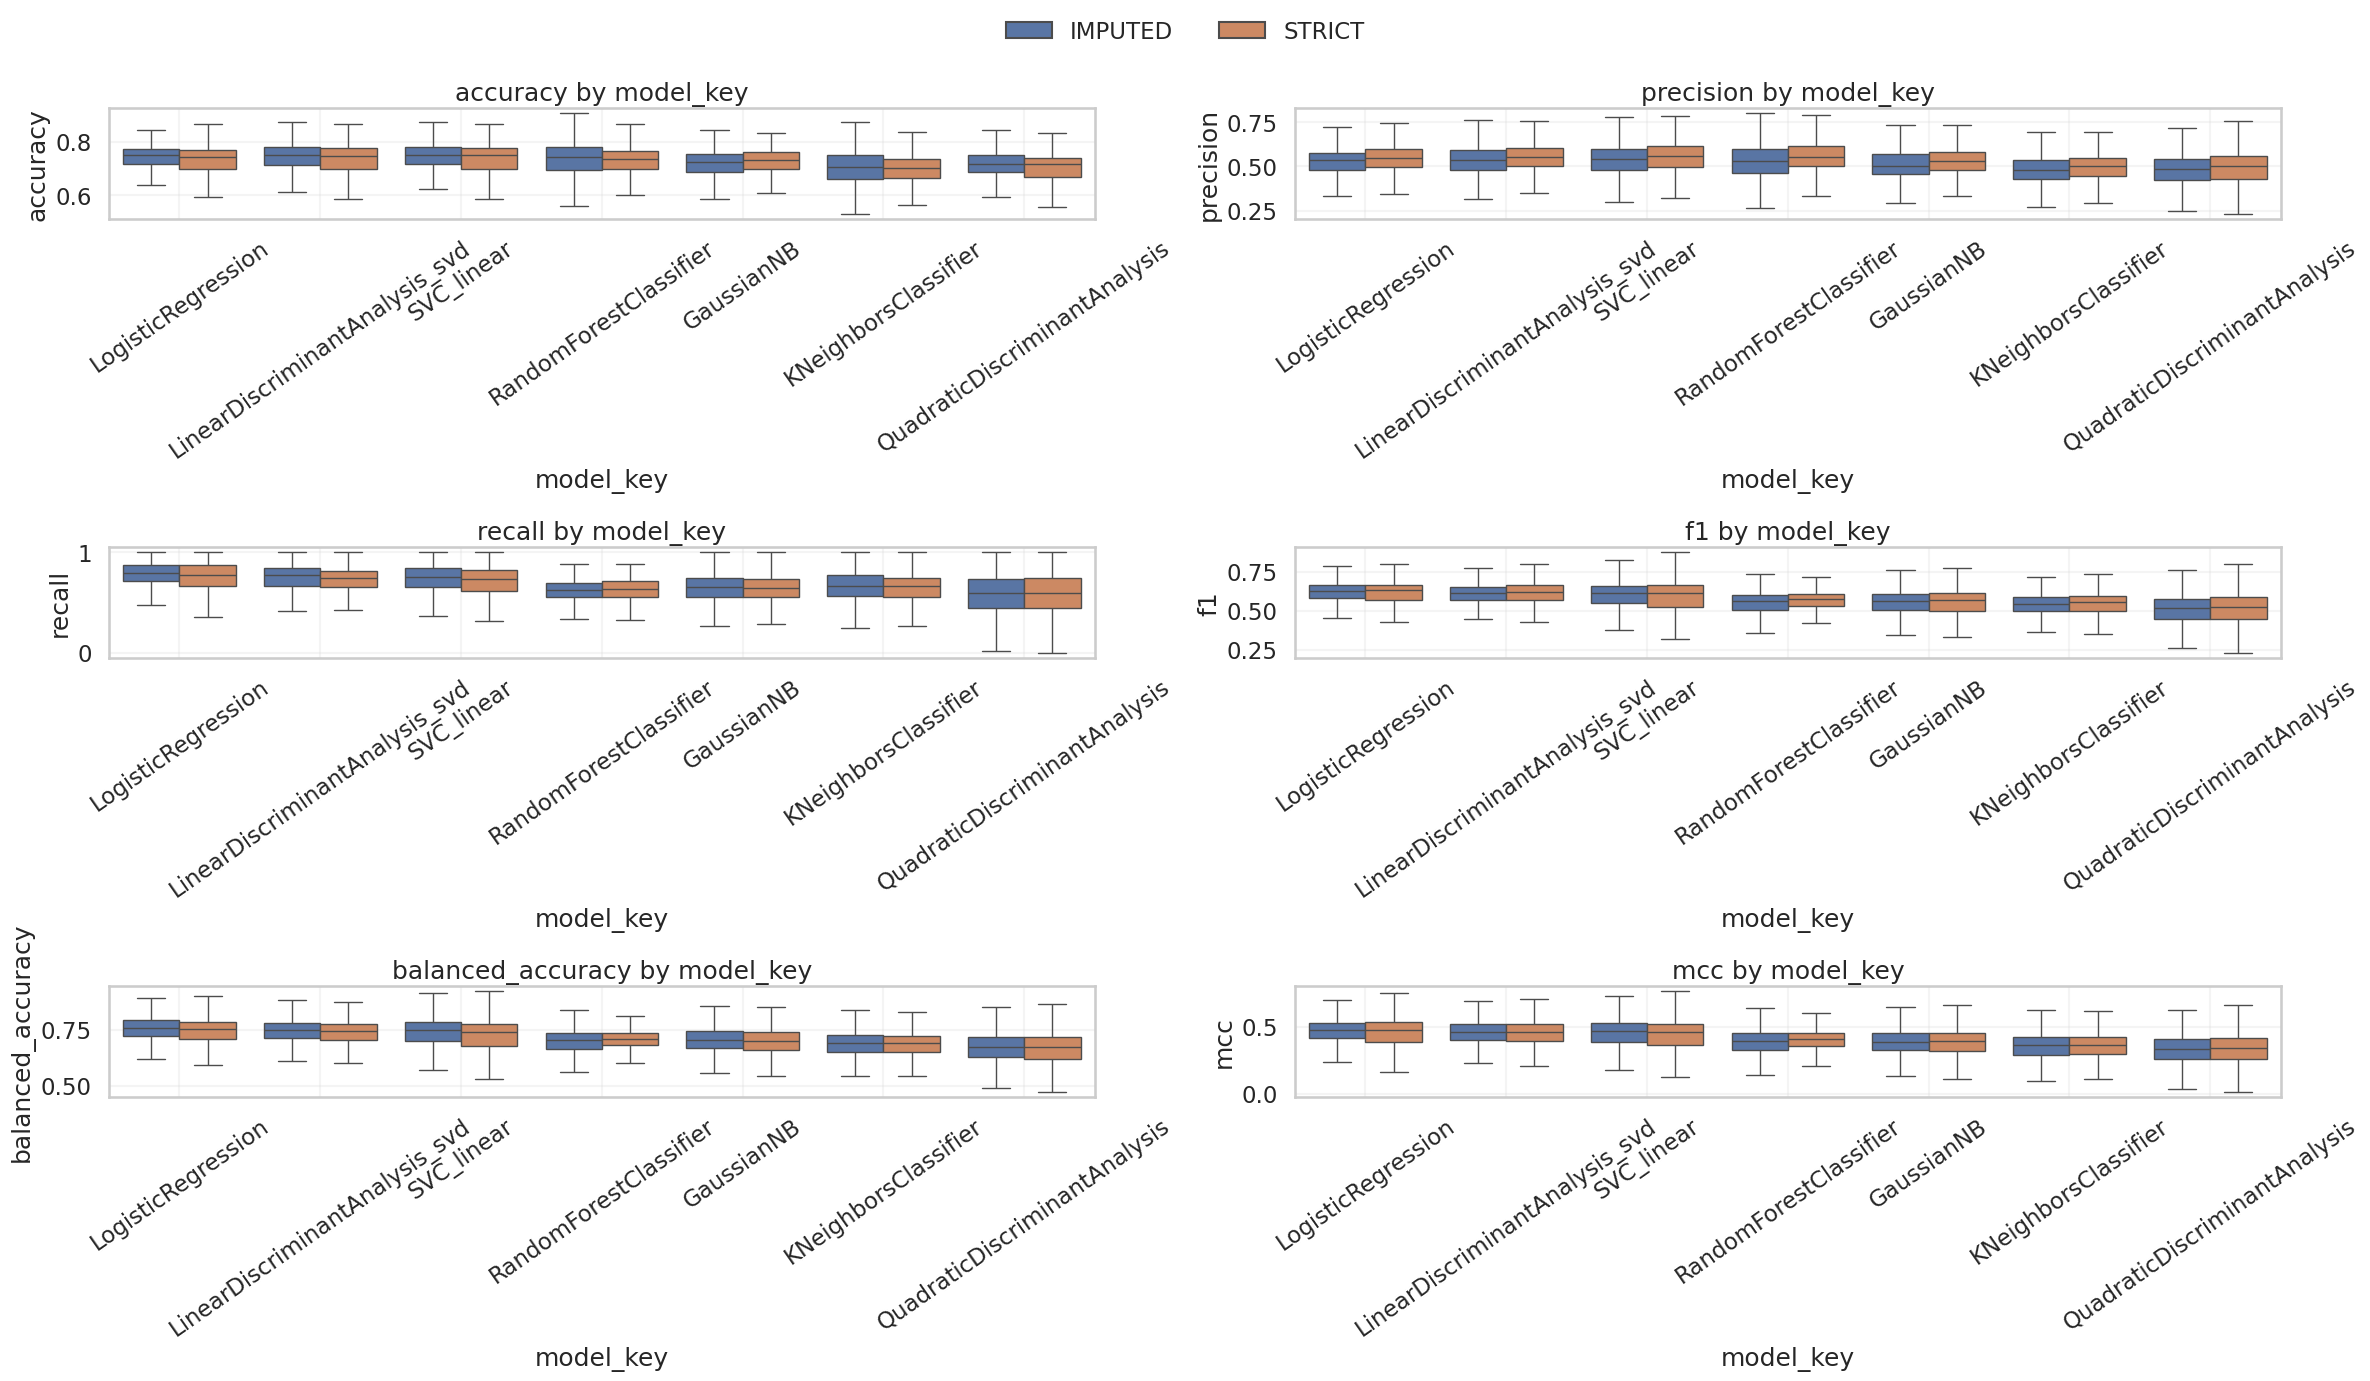

In [12]:
# Model effect
if "model_key" in df.columns and "dataset_variant" in df.columns:
    model_order = (
        df.groupby("model_key")["mcc"]
        .mean()
        .sort_values(ascending=False)
        .index
        .tolist()
        if "mcc" in df.columns else sorted(df["model_key"].unique().tolist())
    )

    fig = plot_factor_boxplots(
        df,
        factor="model_key",
        metrics=present_classical_metrics,
        hue="dataset_variant",
        order=model_order,
        figsize=(24, 14),
    )
    save_figure(fig, "model_key_effect_boxplots.png")
    plt.show()

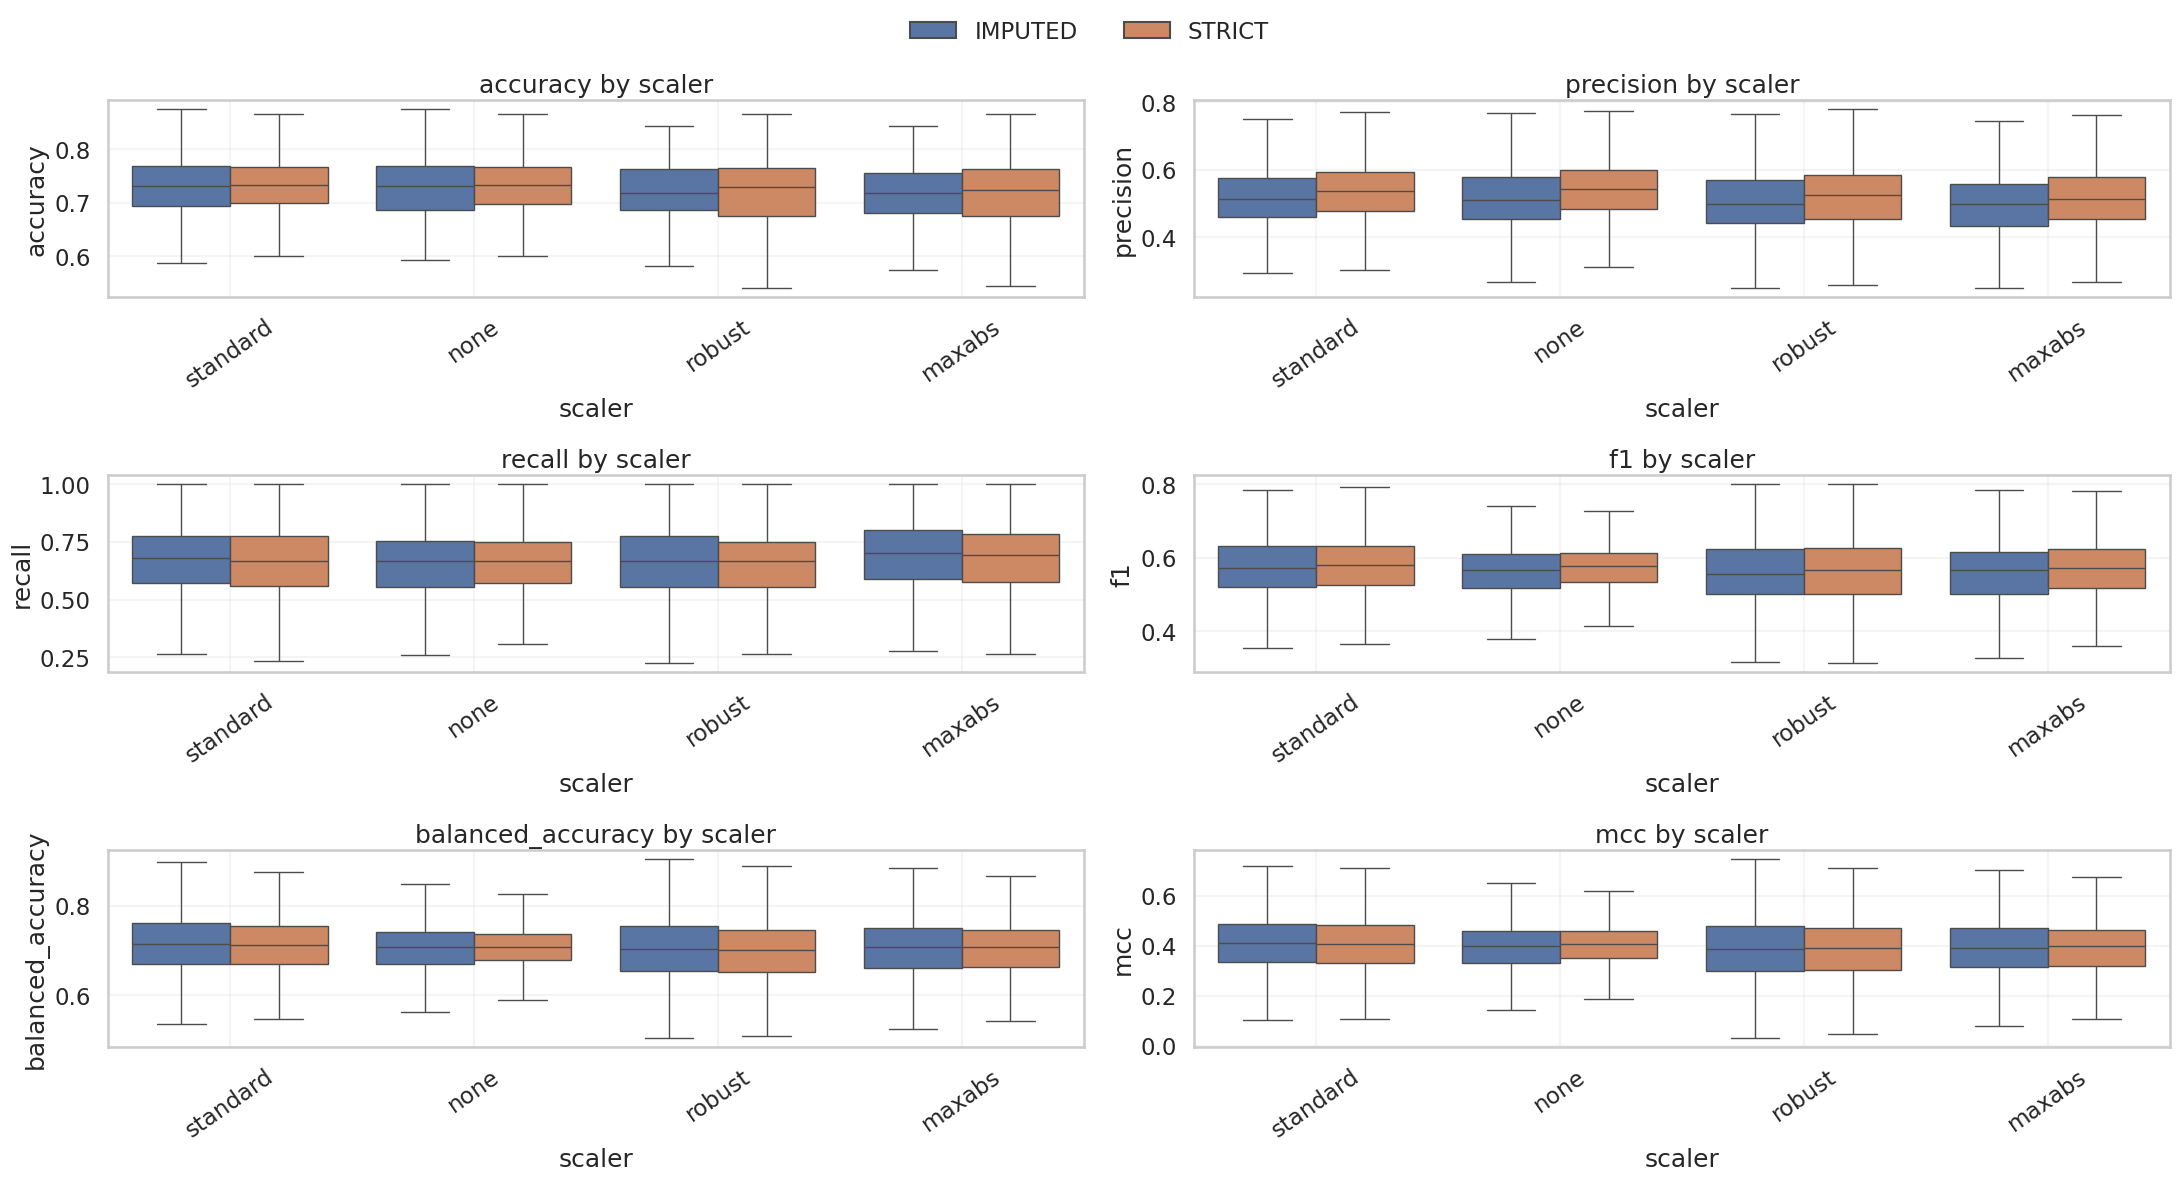

In [13]:
# Scaler effect
if "scaler" in df.columns and "dataset_variant" in df.columns:
    scaler_order = (
        df.groupby("scaler")["mcc"]
        .mean()
        .sort_values(ascending=False)
        .index
        .tolist()
        if "mcc" in df.columns else sorted(df["scaler"].unique().tolist())
    )

    fig = plot_factor_boxplots(
        df,
        factor="scaler",
        metrics=present_classical_metrics,
        hue="dataset_variant",
        order=scaler_order,
        figsize=(22, 12),
    )
    save_figure(fig, "scaler_effect_boxplots.png")
    plt.show()

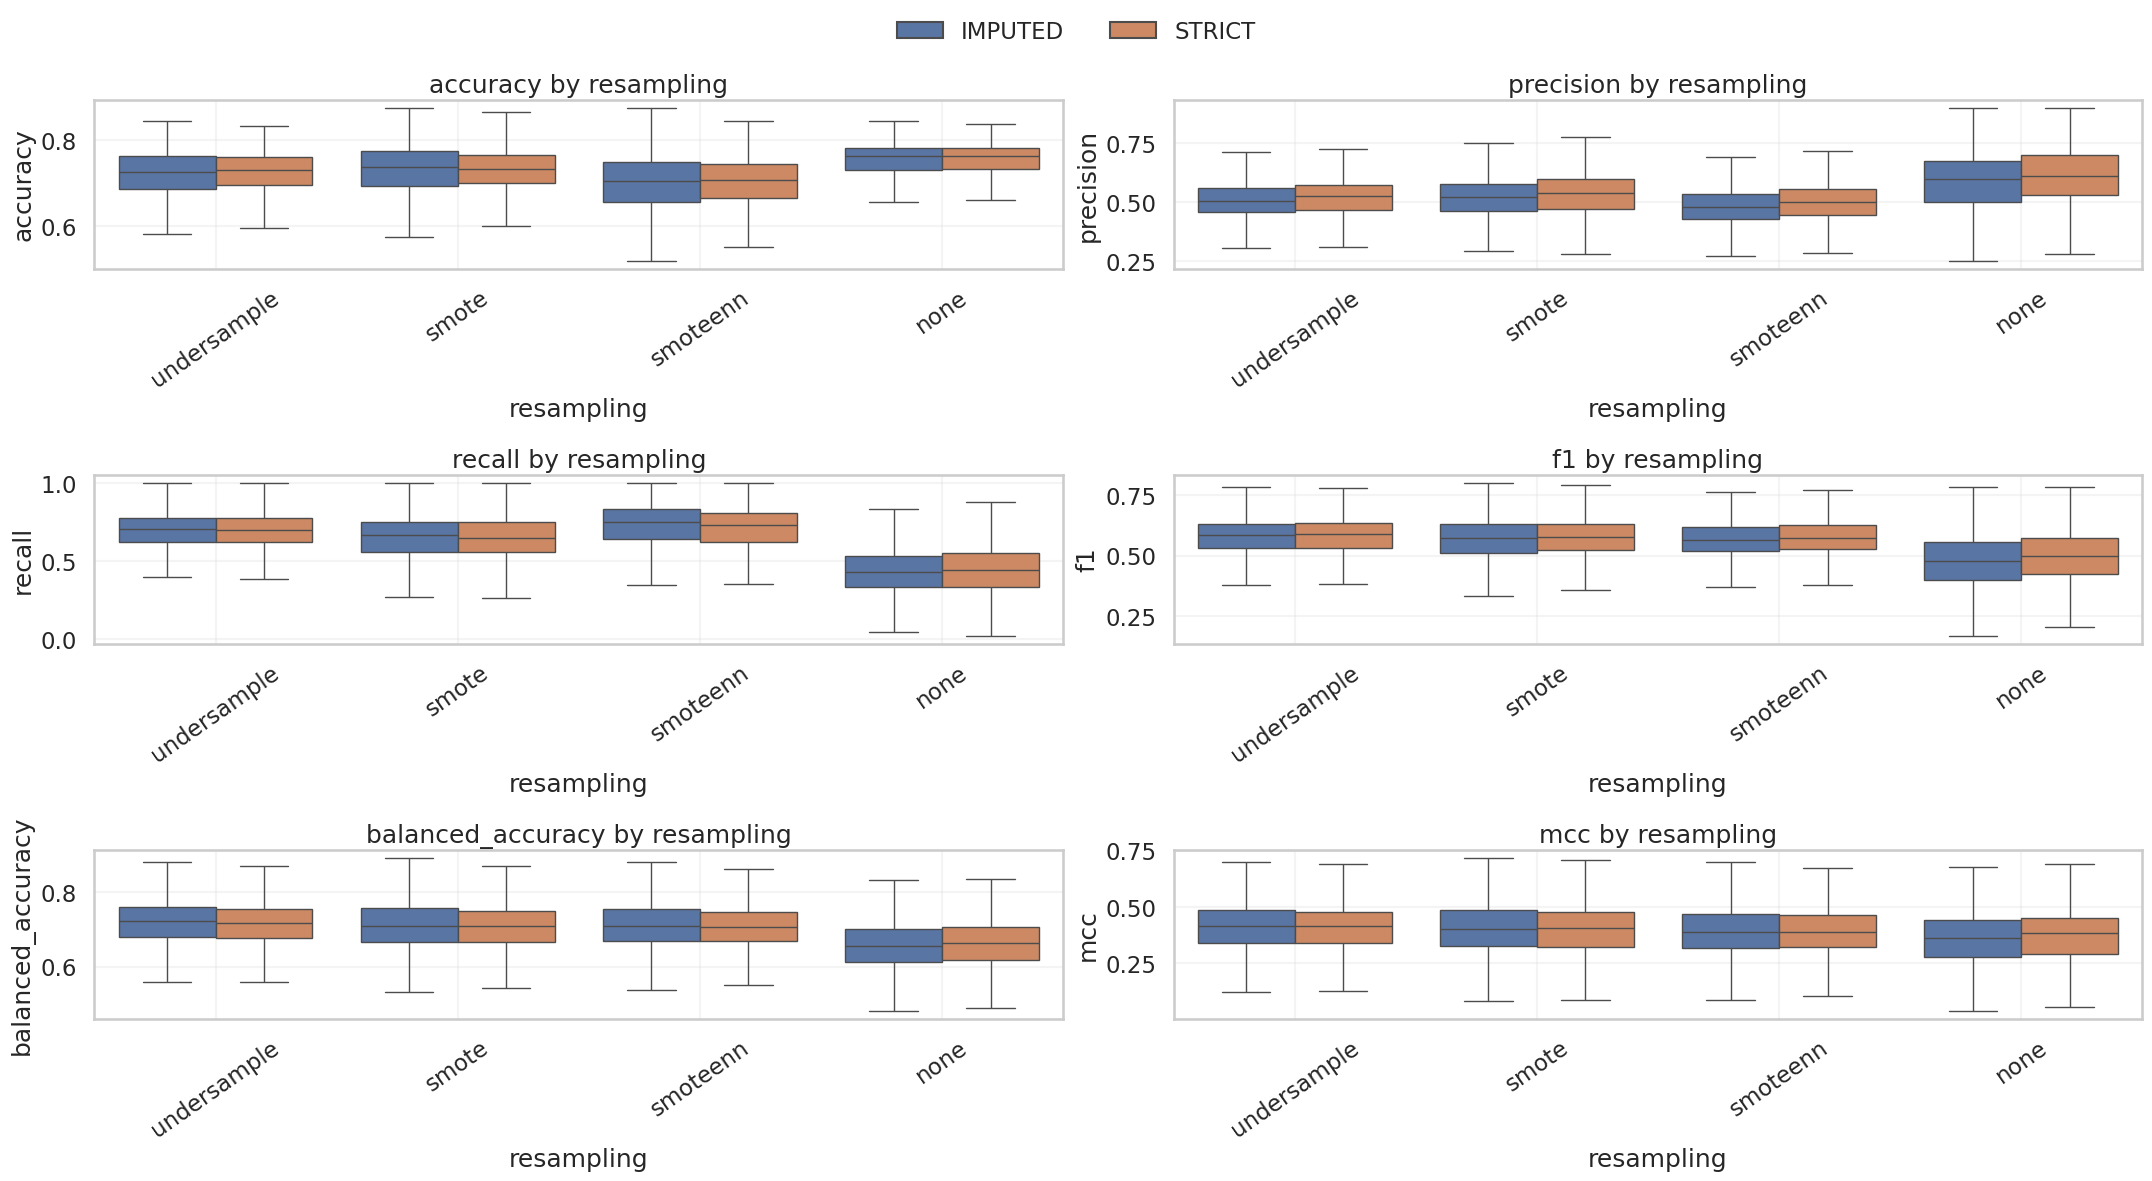

In [14]:
# Resampling effect
if "resampling" in df.columns and "dataset_variant" in df.columns:
    resampling_order = (
        df.groupby("resampling")["mcc"]
        .mean()
        .sort_values(ascending=False)
        .index
        .tolist()
        if "mcc" in df.columns else sorted(df["resampling"].unique().tolist())
    )

    fig = plot_factor_boxplots(
        df,
        factor="resampling",
        metrics=present_classical_metrics,
        hue="dataset_variant",
        order=resampling_order,
        figsize=(22, 12),
    )
    save_figure(fig, "resampling_effect_boxplots.png")
    plt.show()

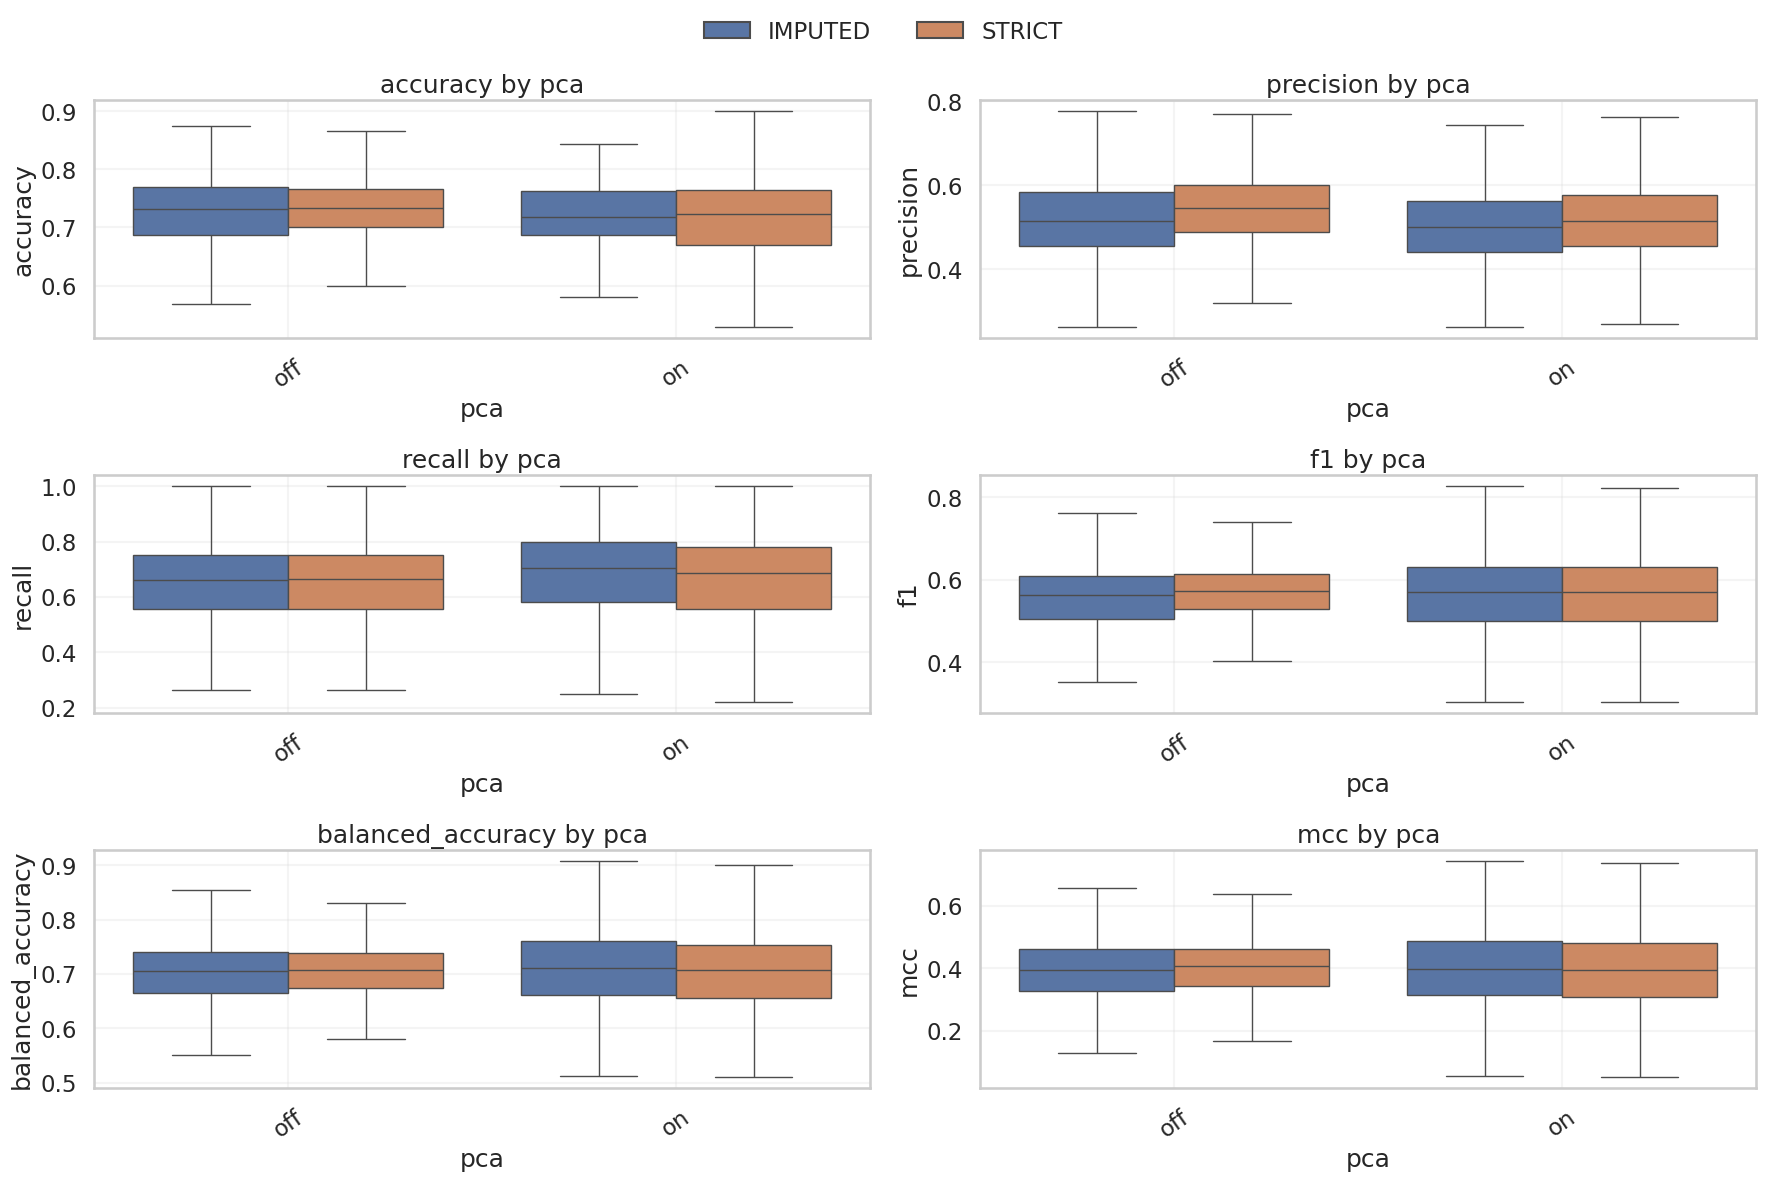

In [15]:
# PCA effect
if "pca" in df.columns and "dataset_variant" in df.columns:
    pca_order = (
        df.groupby("pca")["mcc"]
        .mean()
        .sort_values(ascending=False)
        .index
        .tolist()
        if "mcc" in df.columns else sorted(df["pca"].unique().tolist())
    )

    fig = plot_factor_boxplots(
        df,
        factor="pca",
        metrics=present_classical_metrics,
        hue="dataset_variant",
        order=pca_order,
        figsize=(18, 12),
    )
    save_figure(fig, "pca_effect_boxplots.png")
    plt.show()

## Factor ranking tables

To complement the visual summaries, we derive tables reporting mean, standard deviation, median, and support size for each factor level. These tables are useful for identifying strategies that are not only strong on average, but also sufficiently represented across seeds and configurations.

In [16]:
def factor_ranking_table(
    data: pd.DataFrame,
    factor: str,
    primary_metric: str = "mcc",
    secondary_metrics: list[str] | None = None,
) -> pd.DataFrame:
    if secondary_metrics is None:
        secondary_metrics = ["balanced_accuracy", "f1", "recall", "precision", "accuracy"]

    metrics = [primary_metric] + [m for m in secondary_metrics if m in data.columns and m != primary_metric]
    summary = summarize_factor_effects(data, factor, metrics)

    sort_cols = [f"{primary_metric}_mean"]
    if f"{primary_metric}_std" in summary.columns:
        summary = summary.sort_values(by=[f"{primary_metric}_mean", f"{primary_metric}_std"], ascending=[False, True])

    summary.insert(0, "rank", range(1, len(summary) + 1))
    return summary

ranking_tables = {}
for factor in ["dataset_variant", "config_name", "val_strategy", "model_key", "scaler", "resampling", "pca"]:
    if factor in df.columns and "mcc" in df.columns:
        ranking_tables[factor] = factor_ranking_table(df, factor=factor, primary_metric="mcc")
        print("\n", "#" * 100)
        print(f"Ranking table for {factor}")
        display(ranking_tables[factor])


 ####################################################################################################
Ranking table for dataset_variant


,rank,dataset_variant,mcc_mean,mcc_std,mcc_median,mcc_count,balanced_accuracy_mean,balanced_accuracy_std,balanced_accuracy_median,balanced_accuracy_count,f1_mean,f1_std,f1_median,f1_count,recall_mean,recall_std,recall_median,recall_count,precision_mean,precision_std,precision_median,precision_count,accuracy_mean,accuracy_std,accuracy_median,accuracy_count
0,1,IMPUTED,0.393629,0.144827,0.394815,983978,0.706959,0.078994,0.708333,984040,0.557113,0.117177,0.567772,984040,0.668783,0.181211,0.670000,984040,0.512097,0.128823,0.500000,983978,0.723831,0.075373,0.725000,984040
1,2,STRICT,0.389765,0.135976,0.400066,1016431,0.701852,0.072891,0.706349,1016548,0.559780,0.112826,0.571893,1016548,0.661283,0.175924,0.666667,1016548,0.524315,0.128177,0.528485,1016431,0.717500,0.074873,0.730575,1016548



 ####################################################################################################
Ranking table for config_name


,rank,config_name,mcc_mean,mcc_std,mcc_median,mcc_count,balanced_accuracy_mean,balanced_accuracy_std,balanced_accuracy_median,balanced_accuracy_count,f1_mean,f1_std,f1_median,f1_count,recall_mean,recall_std,recall_median,recall_count,precision_mean,precision_std,precision_median,precision_count,accuracy_mean,accuracy_std,accuracy_median,accuracy_count
3,1,config_strat80,0.395422,0.174881,0.407550,511720,0.701910,0.091174,0.702899,511720,0.570809,0.131556,0.583333,511720,0.658319,0.200227,0.666667,511720,0.539933,0.154843,0.500000,511720,0.719945,0.089959,0.718750,511720
0,2,config_kfold,0.394653,0.093612,0.401234,944152,0.704195,0.052439,0.707594,944152,0.560954,0.087196,0.572051,944152,0.660792,0.145949,0.680000,944152,0.524351,0.085993,0.525653,944152,0.723134,0.050569,0.730115,944152
1,3,config_loo,0.384025,0.090927,0.388371,39610,0.702246,0.054652,0.705975,39789,0.562873,0.084140,0.573913,39789,0.661476,0.147522,0.681818,39789,0.511672,0.072495,0.508475,39610,0.720233,0.050594,0.725000,39789
2,4,config_random80,0.382871,0.173111,0.382971,504927,0.707333,0.095217,0.710227,504927,0.540965,0.140021,0.555556,504927,0.679805,0.209492,0.700000,504927,0.485602,0.159397,0.500000,504927,0.716610,0.095835,0.718750,504927



 ####################################################################################################
Ranking table for val_strategy


...

,rank,scaler,mcc_mean,mcc_std,mcc_median,mcc_count,balanced_accuracy_mean,balanced_accuracy_std,balanced_accuracy_median,balanced_accuracy_count,f1_mean,f1_std,f1_median,f1_count,recall_mean,recall_std,recall_median,recall_count,precision_mean,precision_std,precision_median,precision_count,accuracy_mean,accuracy_std,accuracy_median,accuracy_count
3,1,standard,0.408353,0.129724,0.408187,608312,0.713264,0.070645,0.712560,608312,0.572409,0.097819,0.576084,608312,0.673362,0.161109,0.666667,608312,0.532591,0.114772,0.528137,608312,0.729688,0.066049,0.733333,608312
1,2,none,0.398654,0.116833,0.403021,176435,0.706188,0.061818,0.707727,176435,0.565496,0.087547,0.571429,176435,0.656631,0.145889,0.666667,176435,0.534285,0.117663,0.529762,176435,0.726970,0.066469,0.733333,176435
2,3,robust,0.383606,0.143789,0.387273,608166,0.699899,0.077377,0.701263,608167,0.554180,0.109451,0.560297,608167,0.652613,0.171815,0.666667,608167,0.517735,0.123692,0.508690,608166,0.719549,0.072117,0.725000,608167
0,4,maxabs,0.380994,0.151448,0.394454,607496,0.699393,0.082412,0.706703,607674,0.546764,0.139204,0.571429,607674,0.671364,0.207374,0.695000,607674,0.499930,0.146109,0.500000,607496,0.710750,0.086967,0.720476,607674



 ####################################################################################################
Ranking table for resampling


,rank,resampling,mcc_mean,mcc_std,mcc_median,mcc_count,balanced_accuracy_mean,balanced_accuracy_std,balanced_accuracy_median,balanced_accuracy_count,f1_mean,f1_std,f1_median,f1_count,recall_mean,recall_std,recall_median,recall_count,precision_mean,precision_std,precision_median,precision_count,accuracy_mean,accuracy_std,accuracy_median,accuracy_count
3,1,undersample,0.402283,0.145041,0.413518,363716,0.713926,0.077533,0.720350,363746,0.572769,0.112353,0.587647,363746,0.694368,0.159467,0.700000,363746,0.512187,0.118569,0.517659,363716,0.721273,0.075229,0.729524,363746
1,2,smote,0.398762,0.141646,0.405580,727460,0.708091,0.075058,0.709452,727483,0.565782,0.111335,0.571825,727483,0.652836,0.156408,0.661111,727483,0.527891,0.122376,0.533333,727460,0.731497,0.067434,0.733333,727483
2,3,smoteenn,0.387088,0.132605,0.387830,727476,0.706668,0.072691,0.707630,727482,0.564987,0.099932,0.571429,727482,0.718756,0.160128,0.736111,727482,0.492325,0.110107,0.496905,727476,0.699920,0.081301,0.706250,727482
0,4,none,0.360336,0.150735,0.374631,181757,0.661116,0.075547,0.660000,181877,0.474540,0.151162,0.493761,181877,0.439597,0.186688,0.435000,181877,0.596168,0.190600,0.600000,181757,0.758538,0.051076,0.762500,181877



 ####################################################################################################
Ranking table for pca


,rank,pca,mcc_mean,mcc_std,mcc_median,mcc_count,balanced_accuracy_mean,balanced_accuracy_std,balanced_accuracy_median,balanced_accuracy_count,f1_mean,f1_std,f1_median,f1_count,recall_mean,recall_std,recall_median,recall_count,precision_mean,precision_std,precision_median,precision_count,accuracy_mean,accuracy_std,accuracy_median,accuracy_count
0,1,off,0.396014,0.121685,0.400629,705201,0.703989,0.064457,0.706349,705226,0.561534,0.094958,0.571429,705226,0.646122,0.152941,0.661111,705226,0.535293,0.121556,0.533333,705201,0.728426,0.068124,0.733333,705226
1,2,on,0.389298,0.149574,0.395794,1295208,0.704568,0.081596,0.708333,1295362,0.556799,0.124523,0.571429,1295362,0.675235,0.190320,0.692308,1295362,0.509056,0.131419,0.503030,1295208,0.716361,0.078438,0.722989,1295362


## Interaction analysis

Marginal effects are informative, but many pipeline decisions are not independent. This section explores key pairwise interactions, especially those likely to affect model behavior in non-additive ways.

In [17]:
def interaction_heatmap(
    data: pd.DataFrame,
    row_factor: str,
    col_factor: str,
    metric: str = "mcc",
    aggfunc: str = "mean",
    figsize: tuple[int, int] = (10, 6),
    annot: bool = True,
    fmt: str = ".3f",
    cmap: str = "viridis",
):
    plot_df = data.loc[data[metric].notna()].copy()
    pivot = plot_df.pivot_table(
        values=metric,
        index=row_factor,
        columns=col_factor,
        aggfunc=aggfunc,
    )
    fig, ax = plt.subplots(figsize=figsize)
    sns.heatmap(pivot, annot=annot, fmt=fmt, cmap=cmap, ax=ax)
    ax.set_title(f"{metric} ({aggfunc}) for {row_factor} × {col_factor}")
    plt.tight_layout()
    return fig, pivot

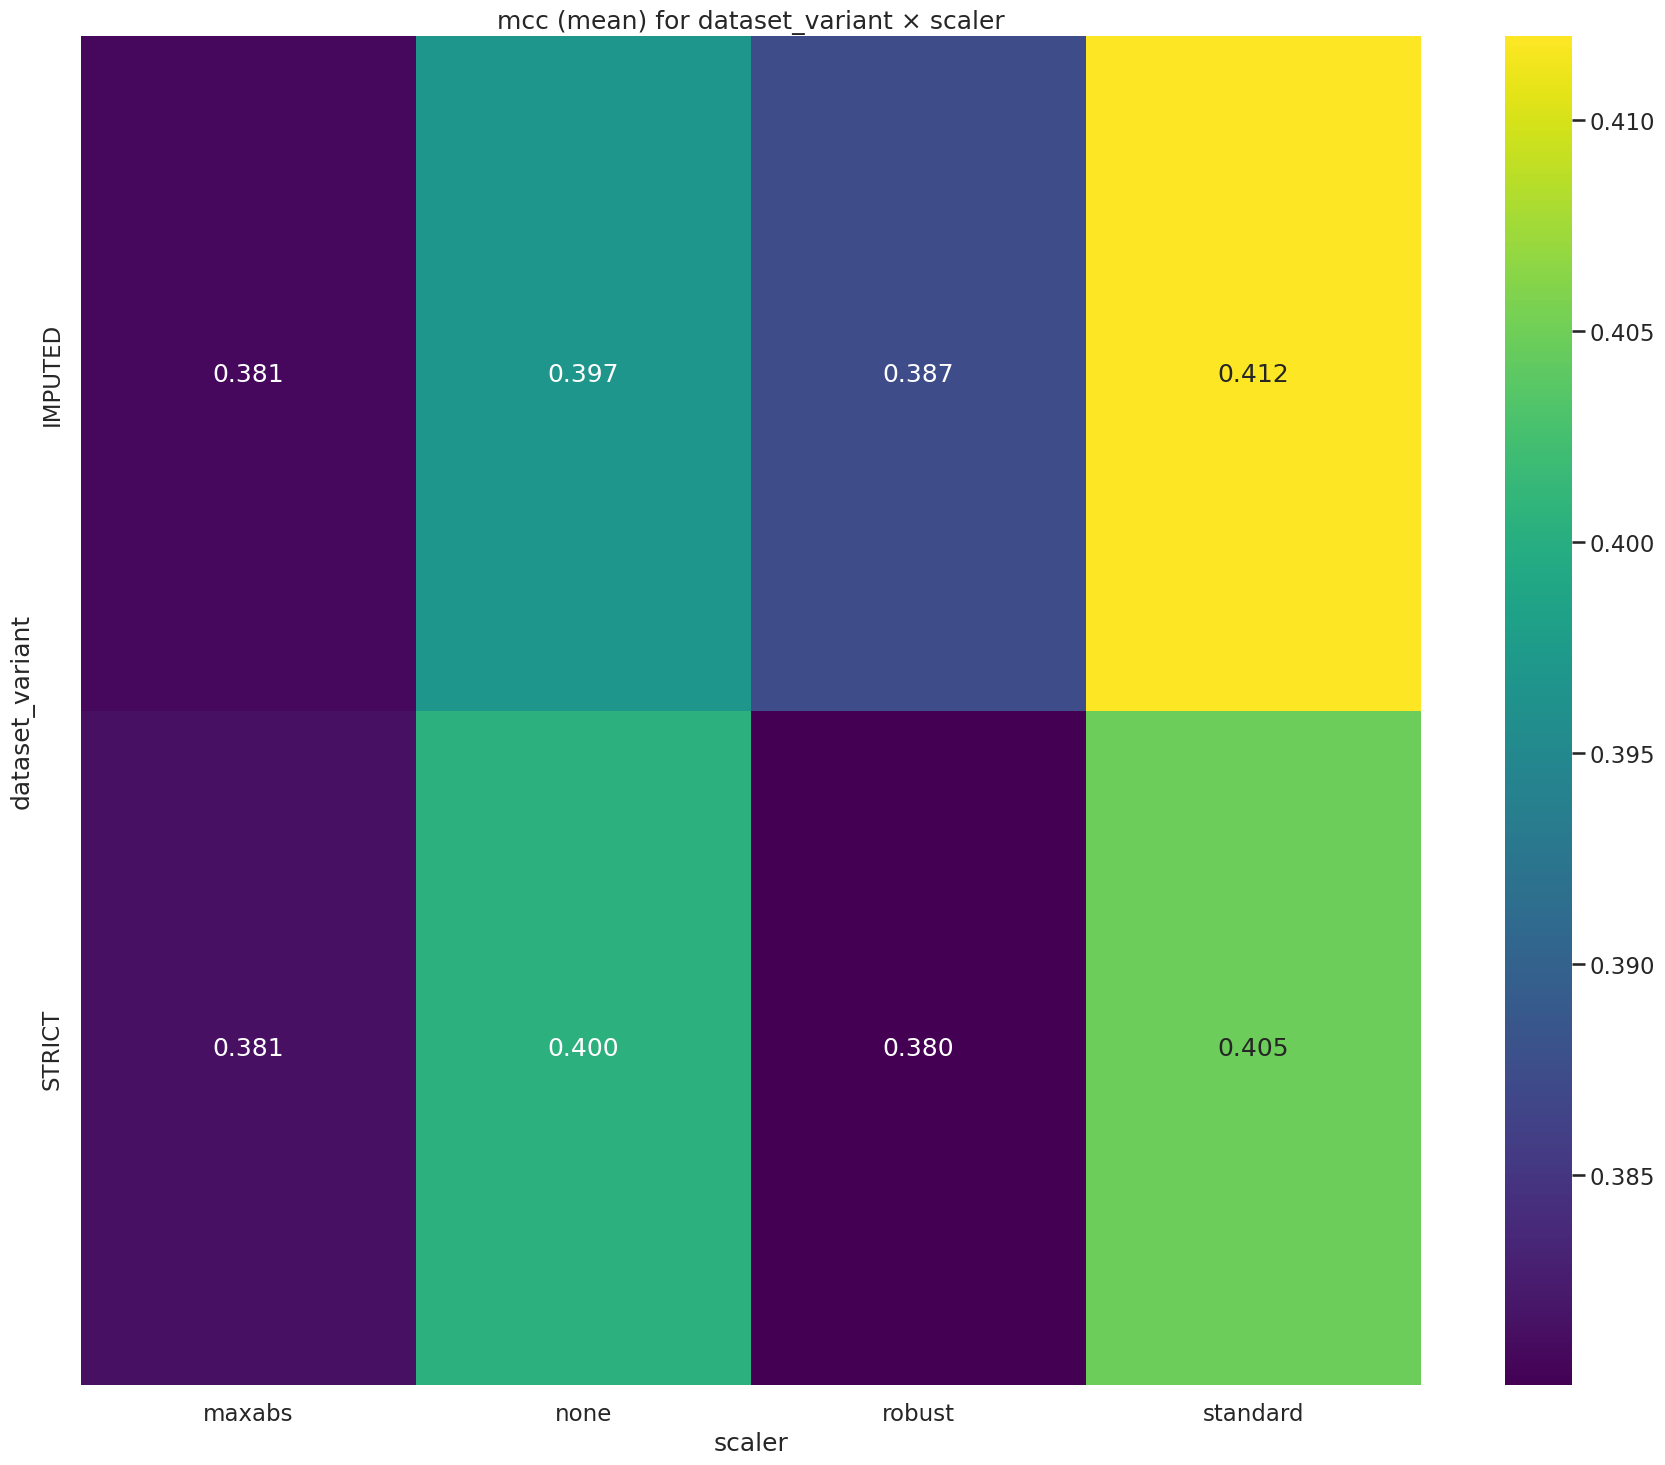

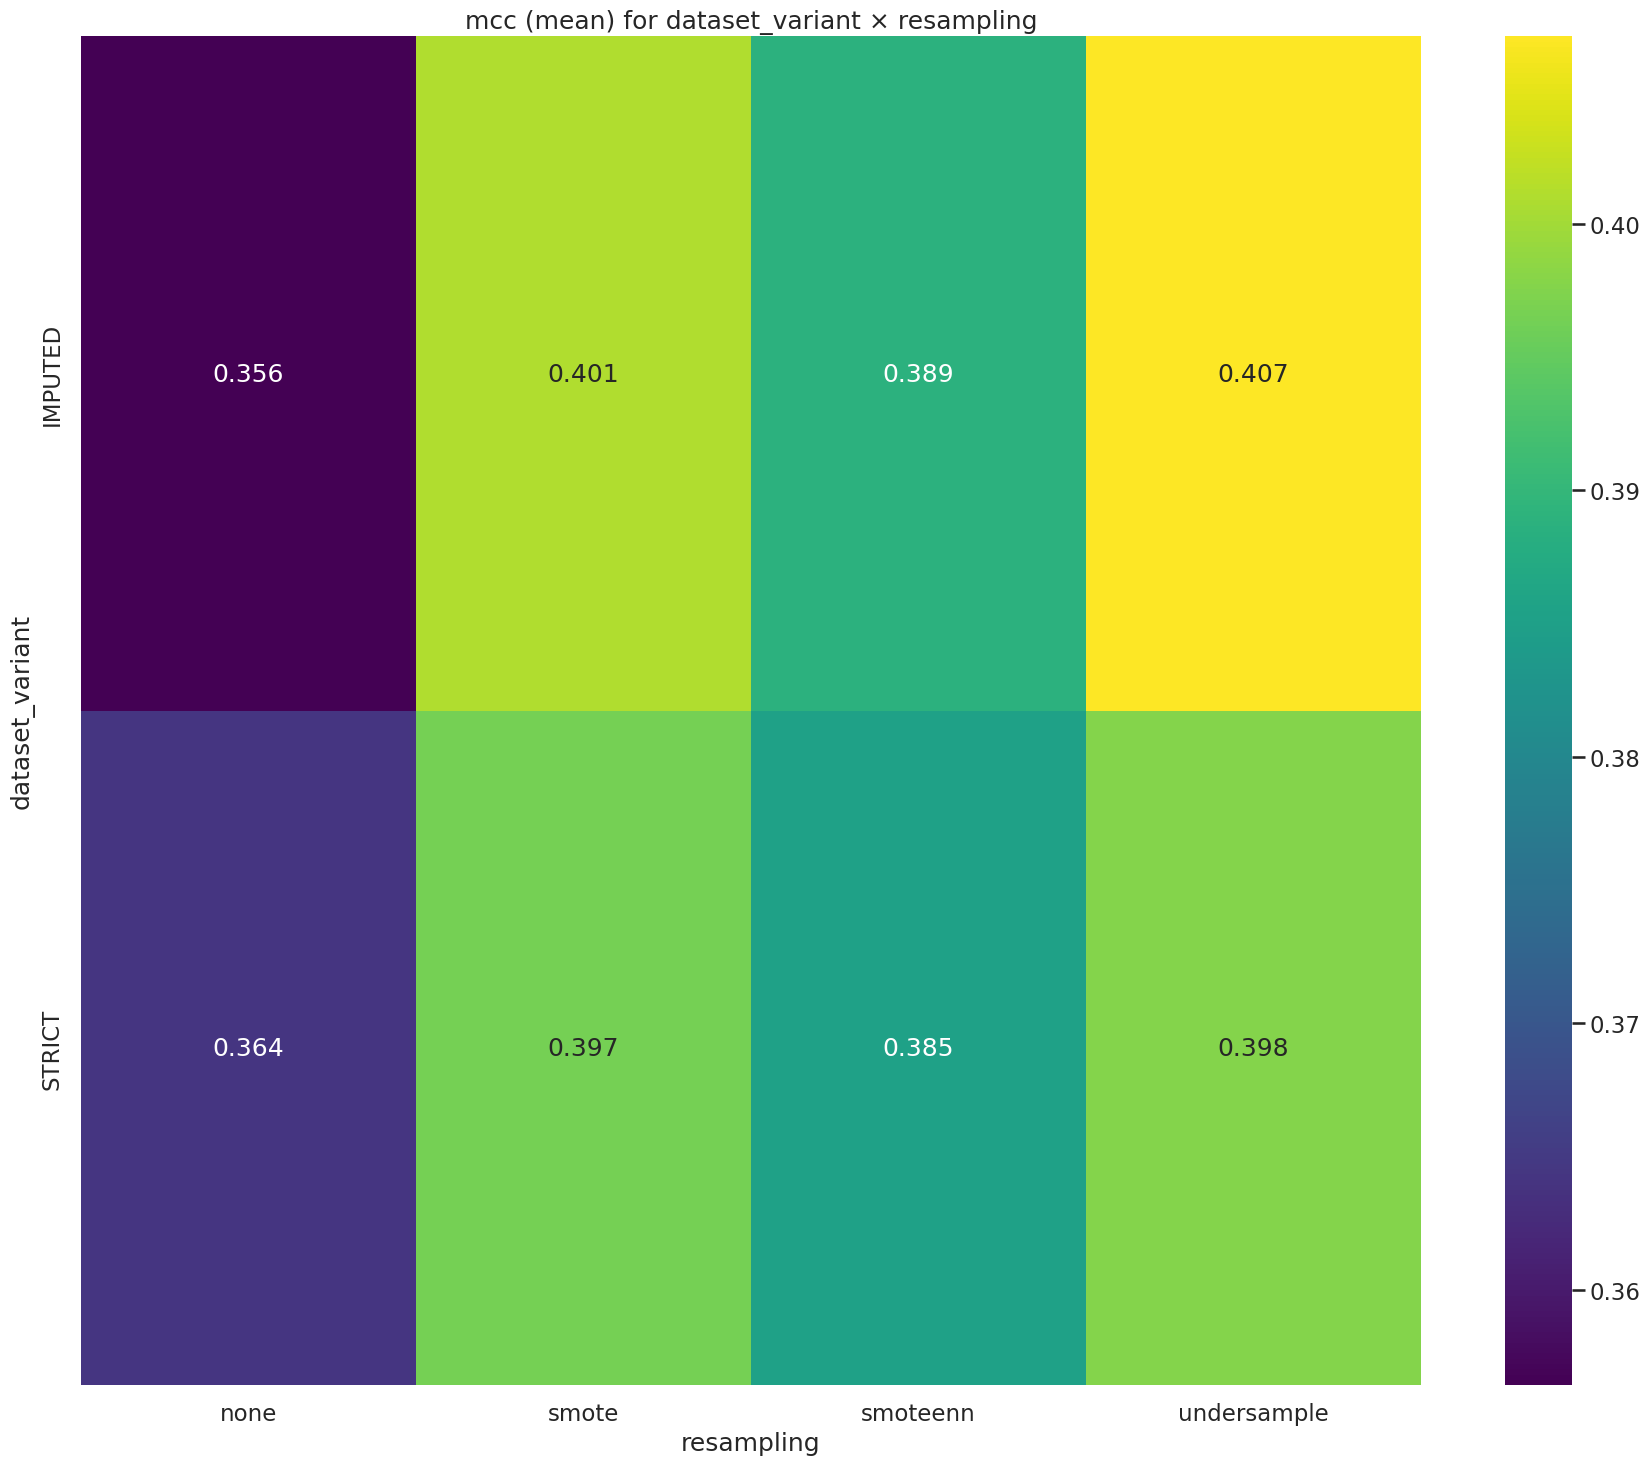

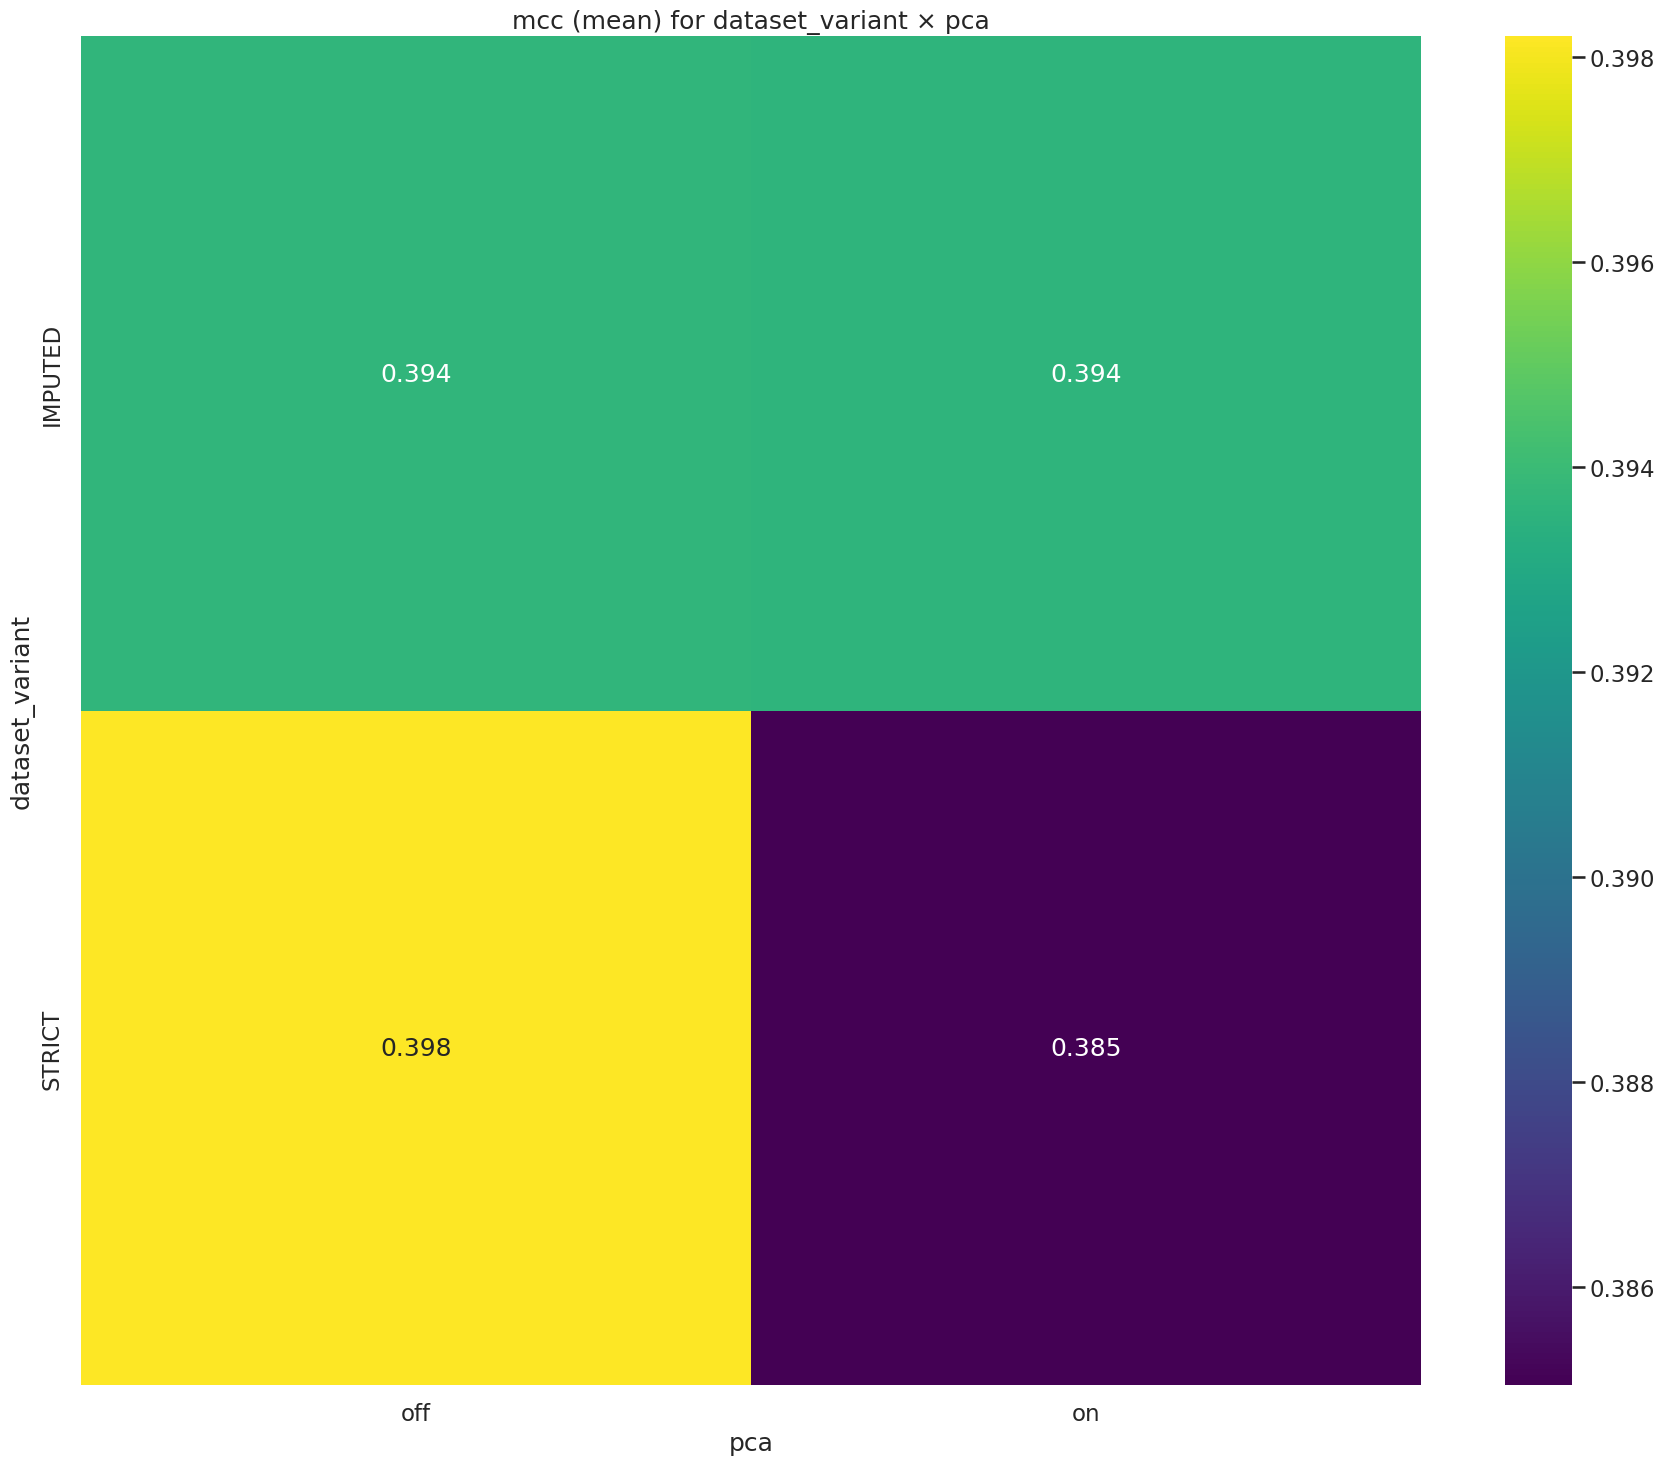

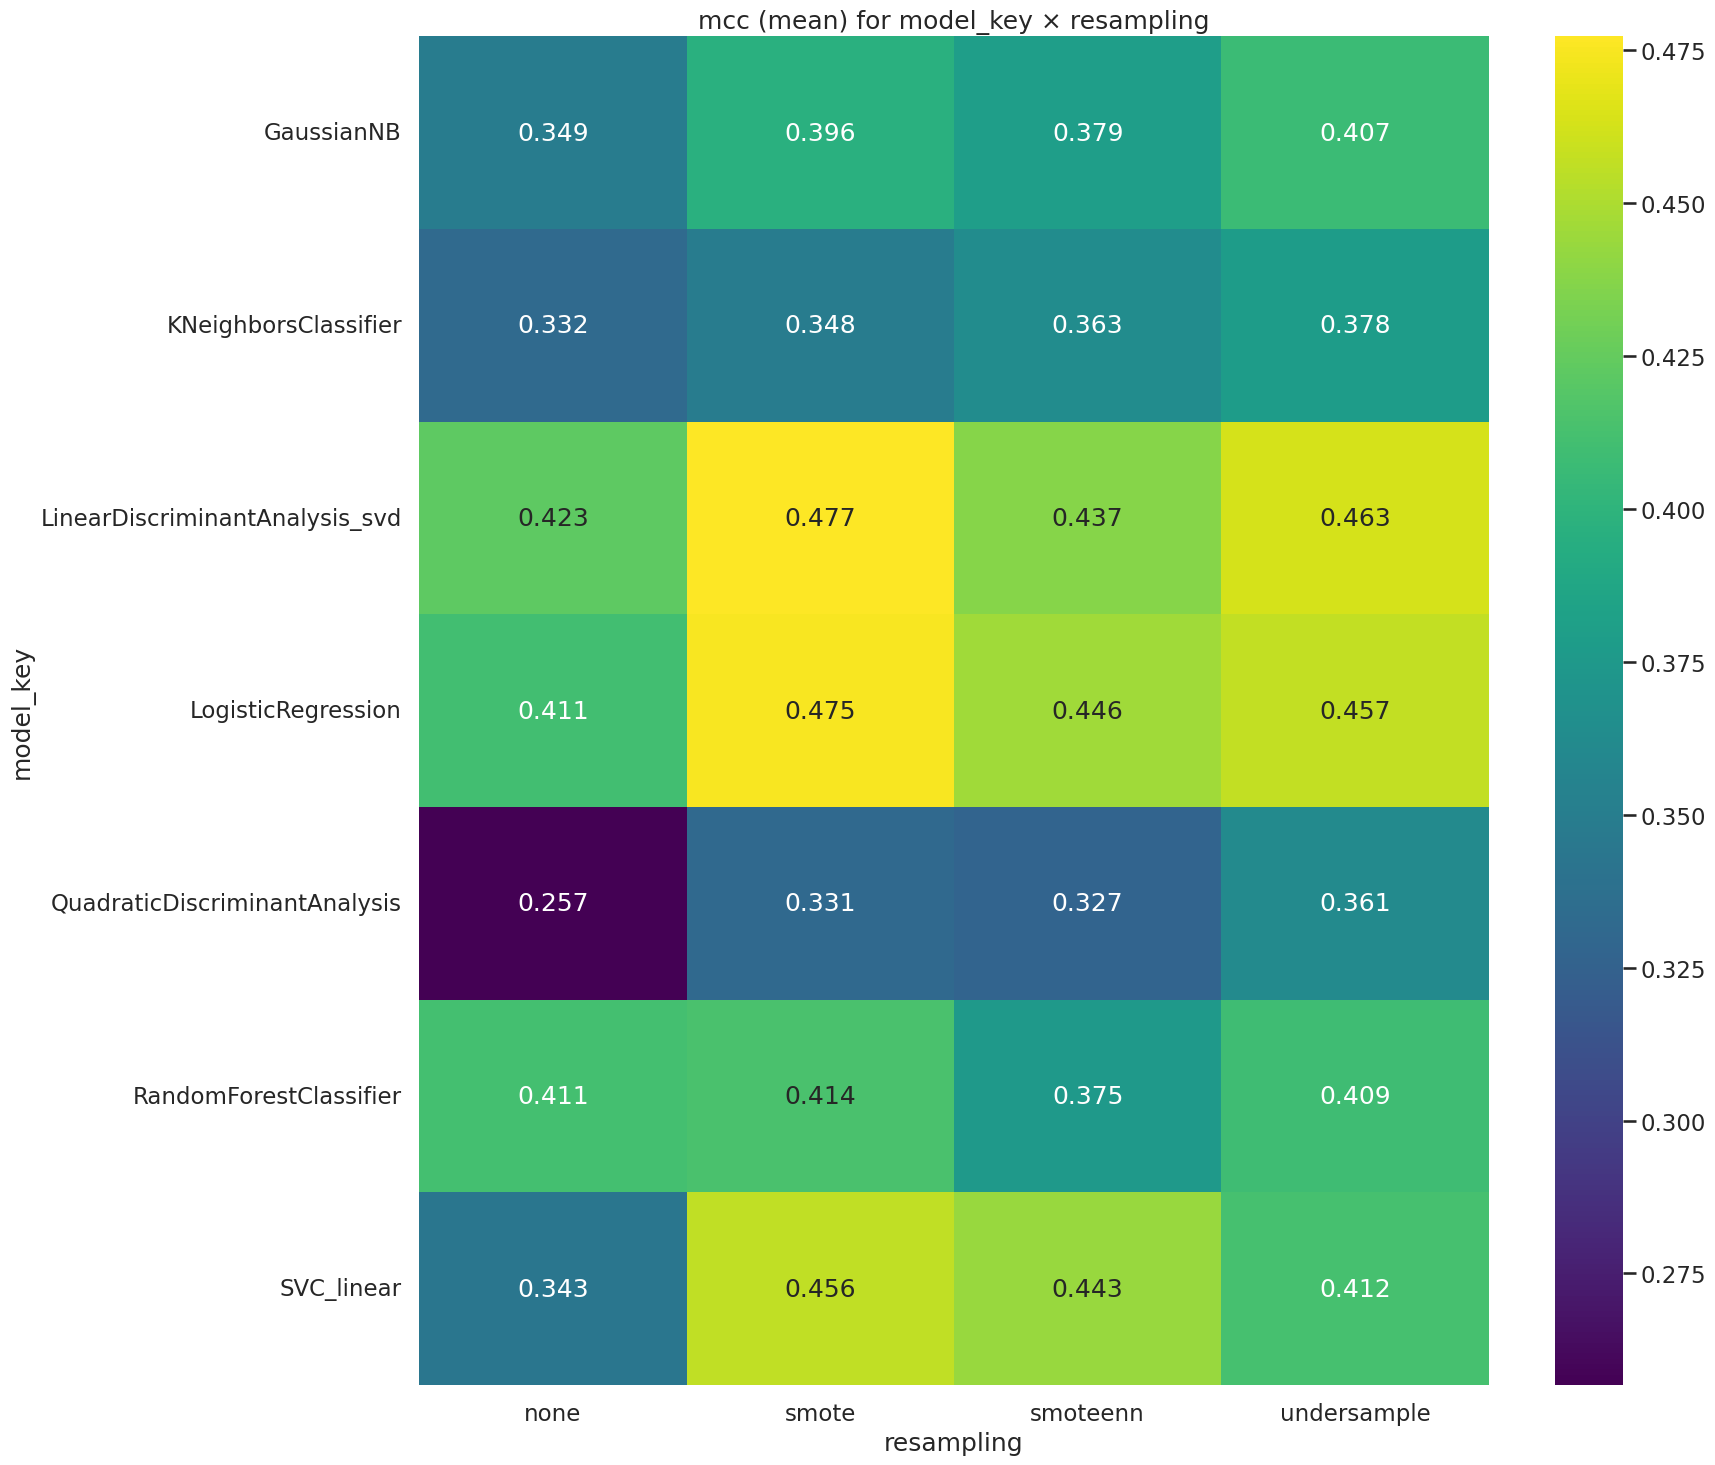

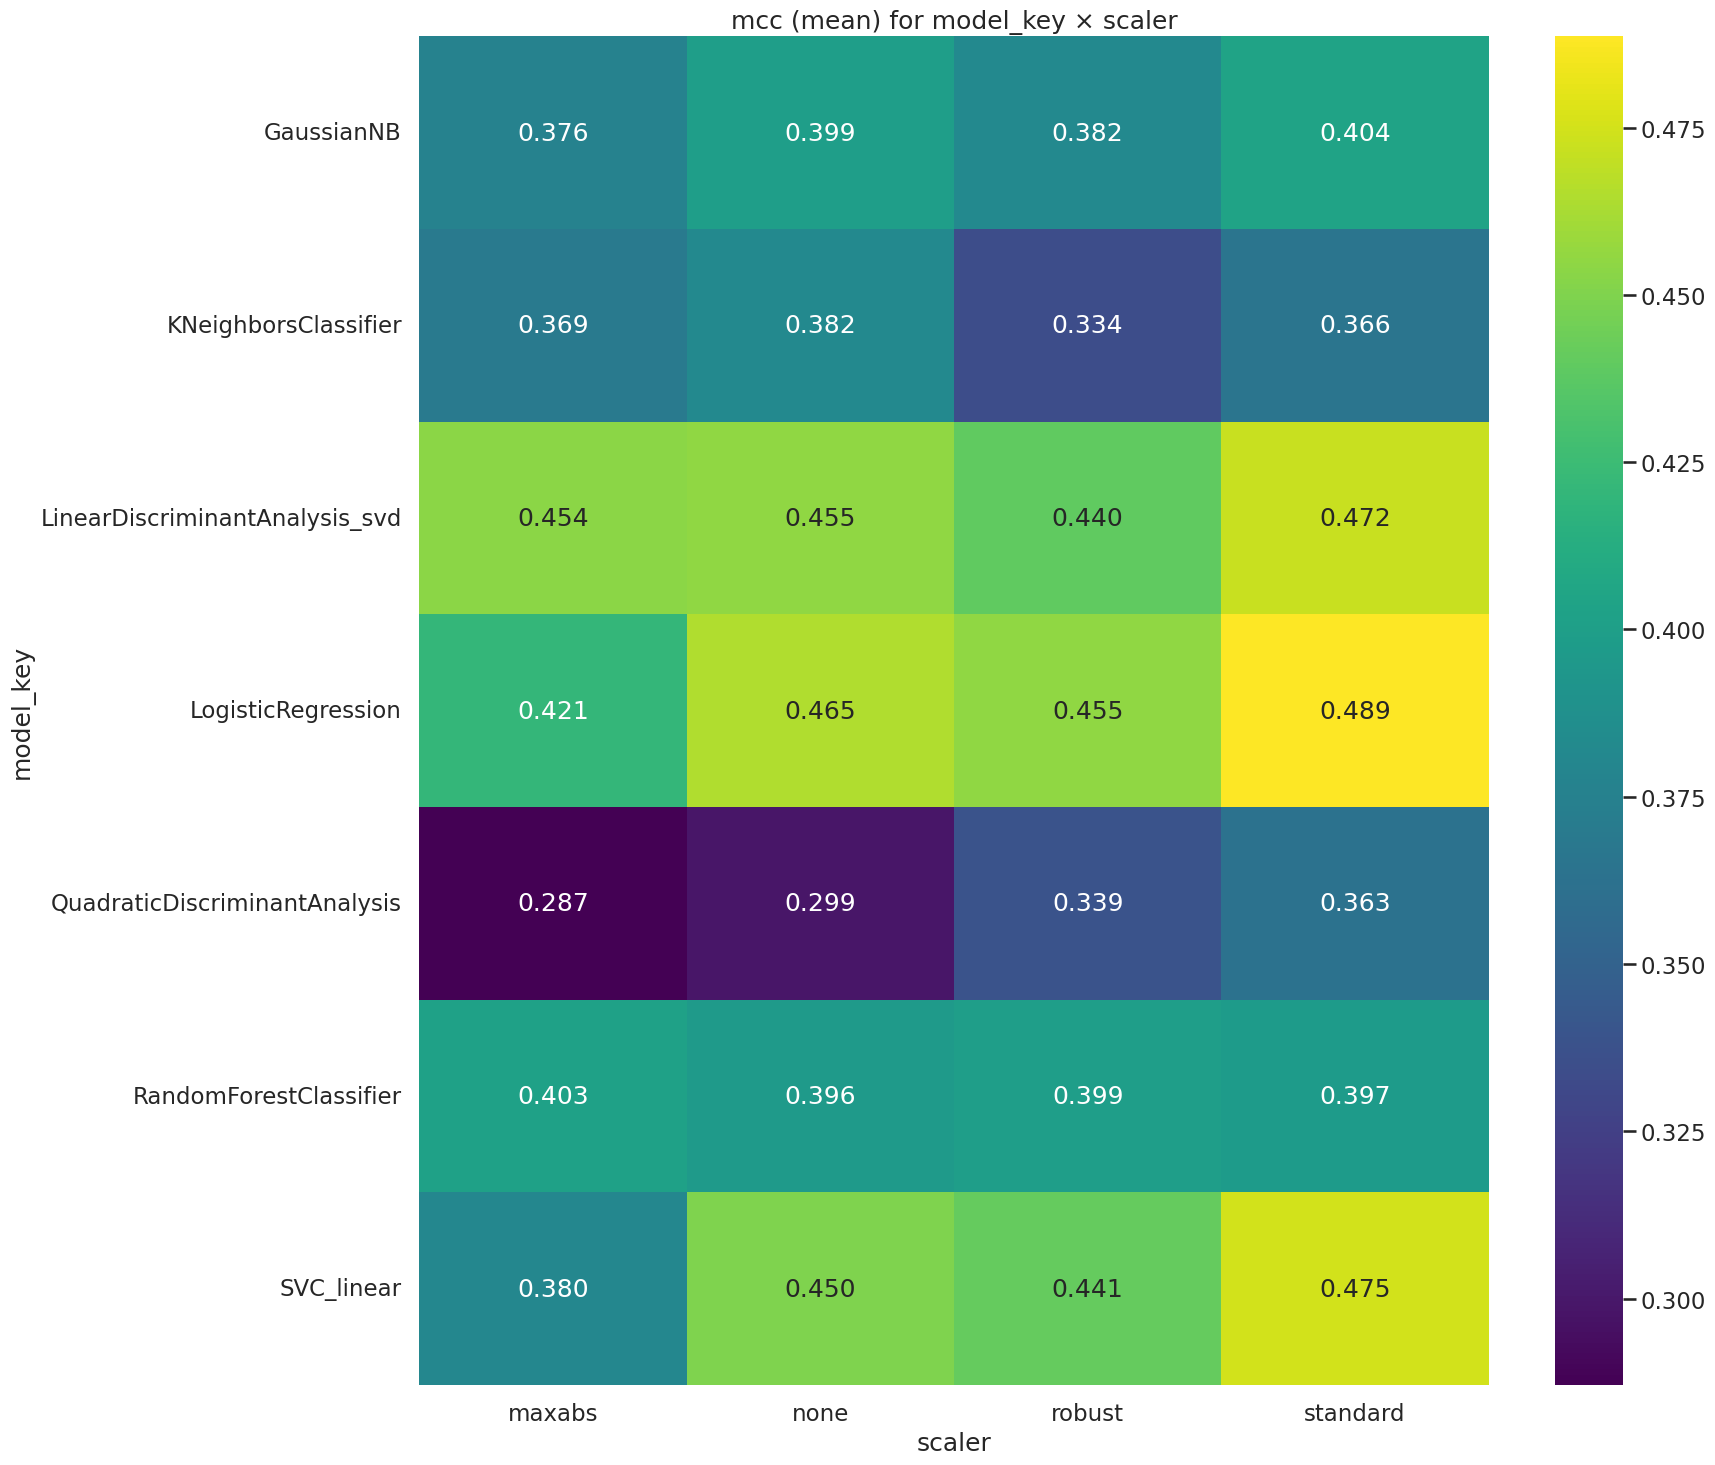

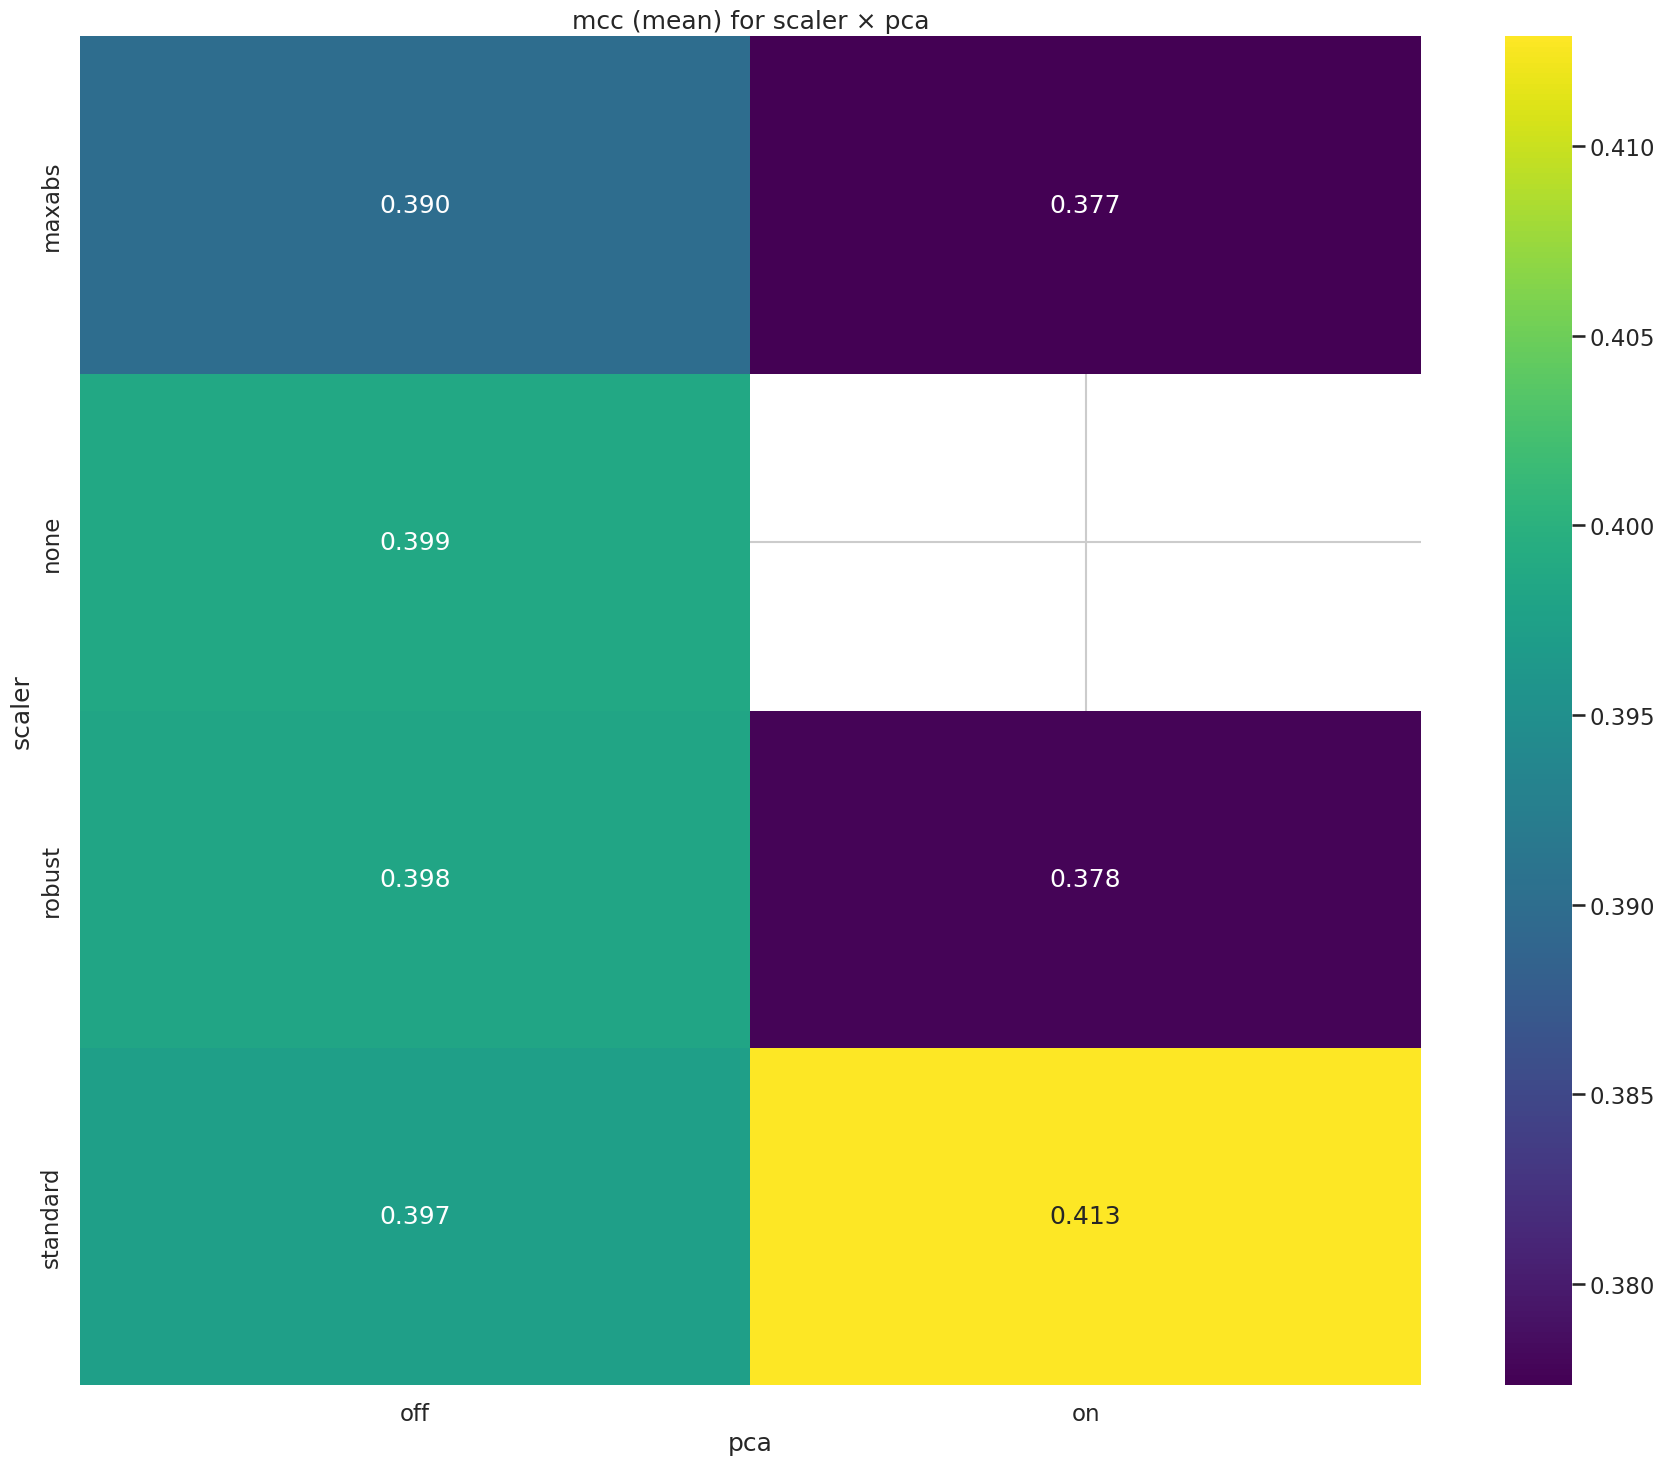

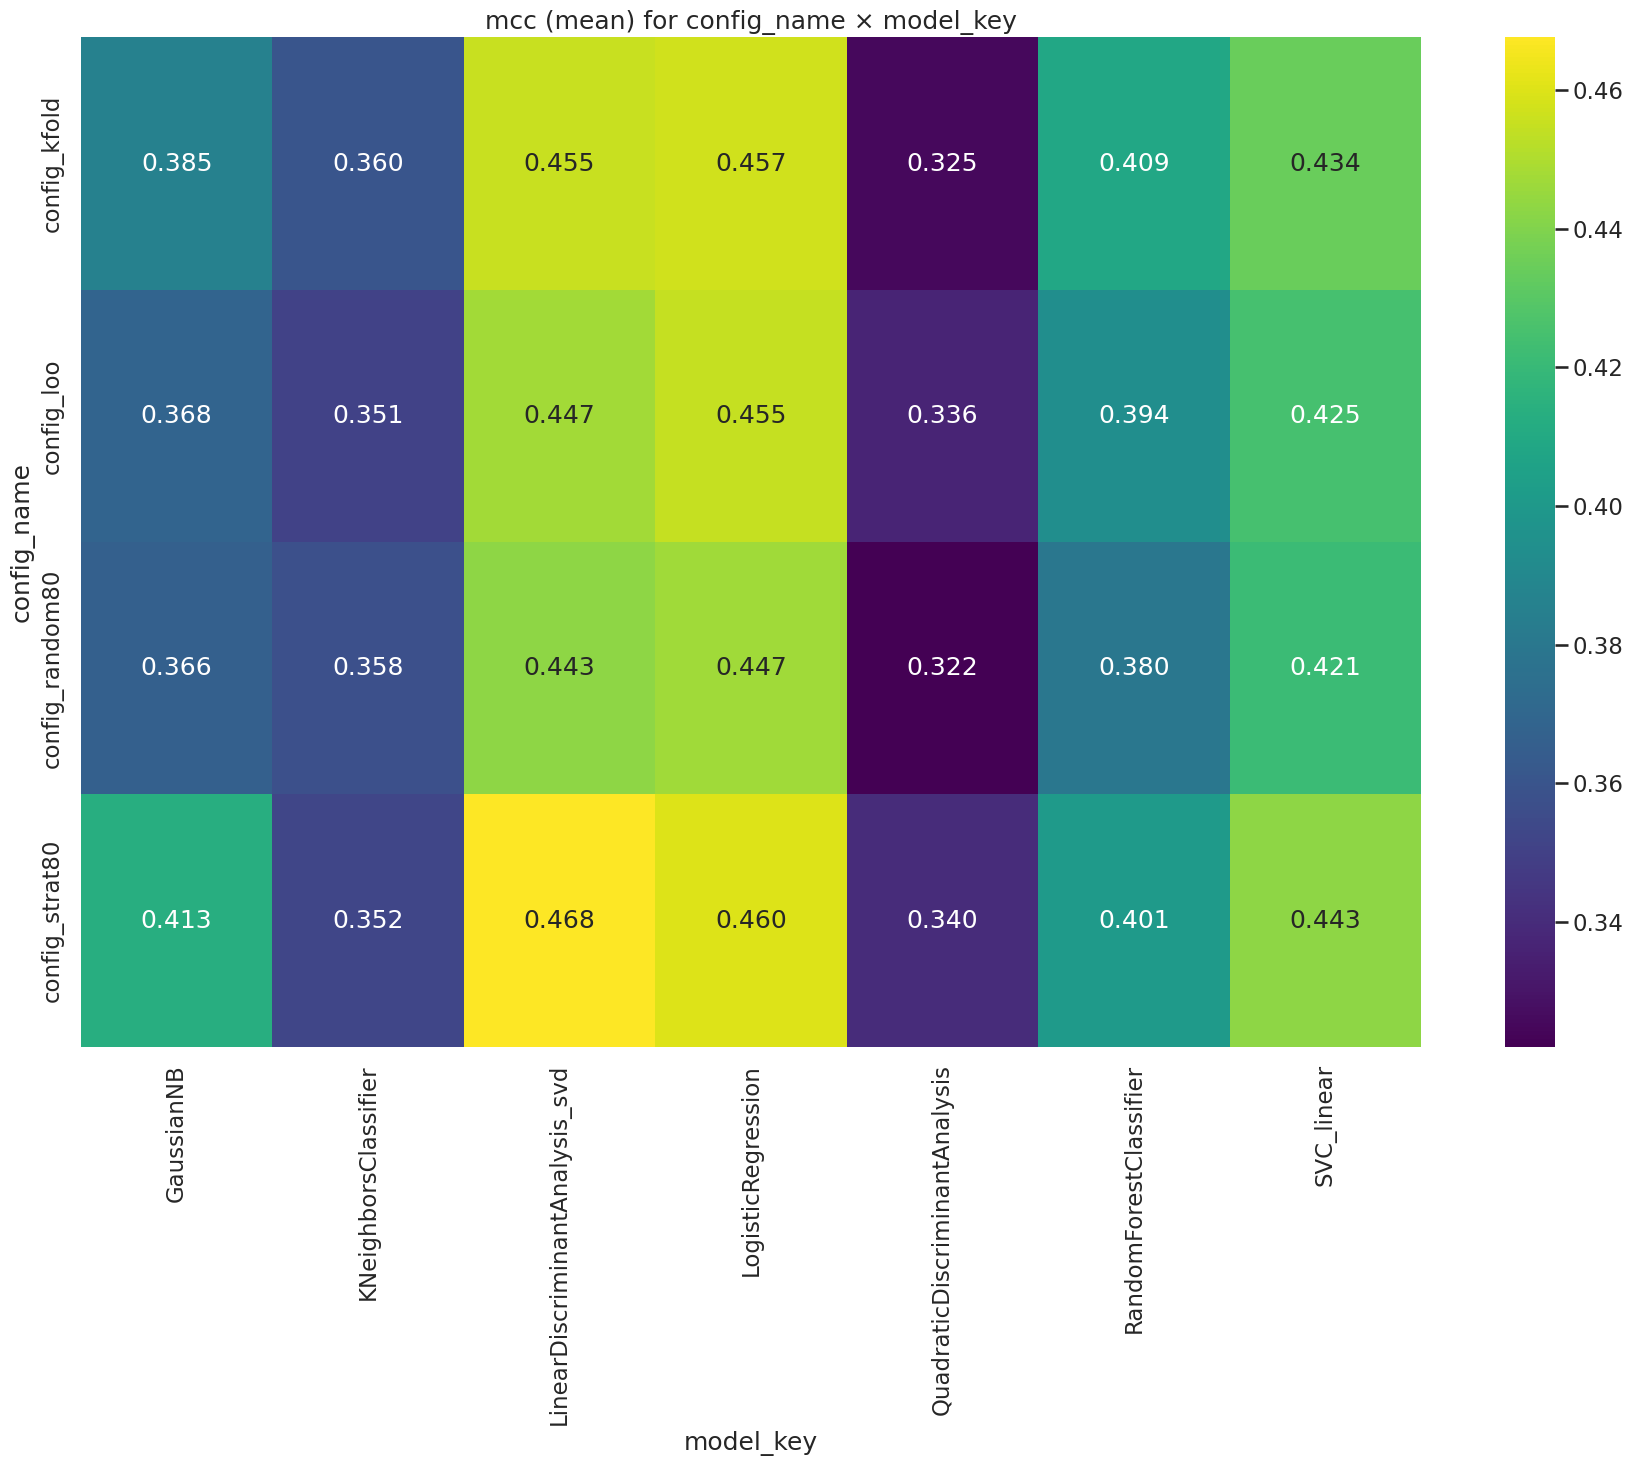

In [26]:
interaction_specs = [
    ("dataset_variant", "scaler"),
    ("dataset_variant", "resampling"),
    ("dataset_variant", "pca"),
    ("model_key", "resampling"),
    ("model_key", "scaler"),
    ("scaler", "pca"),
    ("config_name", "model_key"),
]

interaction_tables = {}

for row_factor, col_factor in interaction_specs:
    if row_factor in df.columns and col_factor in df.columns and "mcc" in df.columns:
        fig, pivot = interaction_heatmap(
            df,
            row_factor=row_factor,
            col_factor=col_factor,
            metric="mcc",
            aggfunc="mean",
            figsize=(max(18, 1.2 * df[row_factor].nunique()), max(15, 0.8 * df[col_factor].nunique())),
        )
        interaction_tables[f"{row_factor}__{col_factor}"] = pivot
        save_figure(fig, f"heatmap_{row_factor}__{col_factor}__mcc_mean.png")
        plt.show()

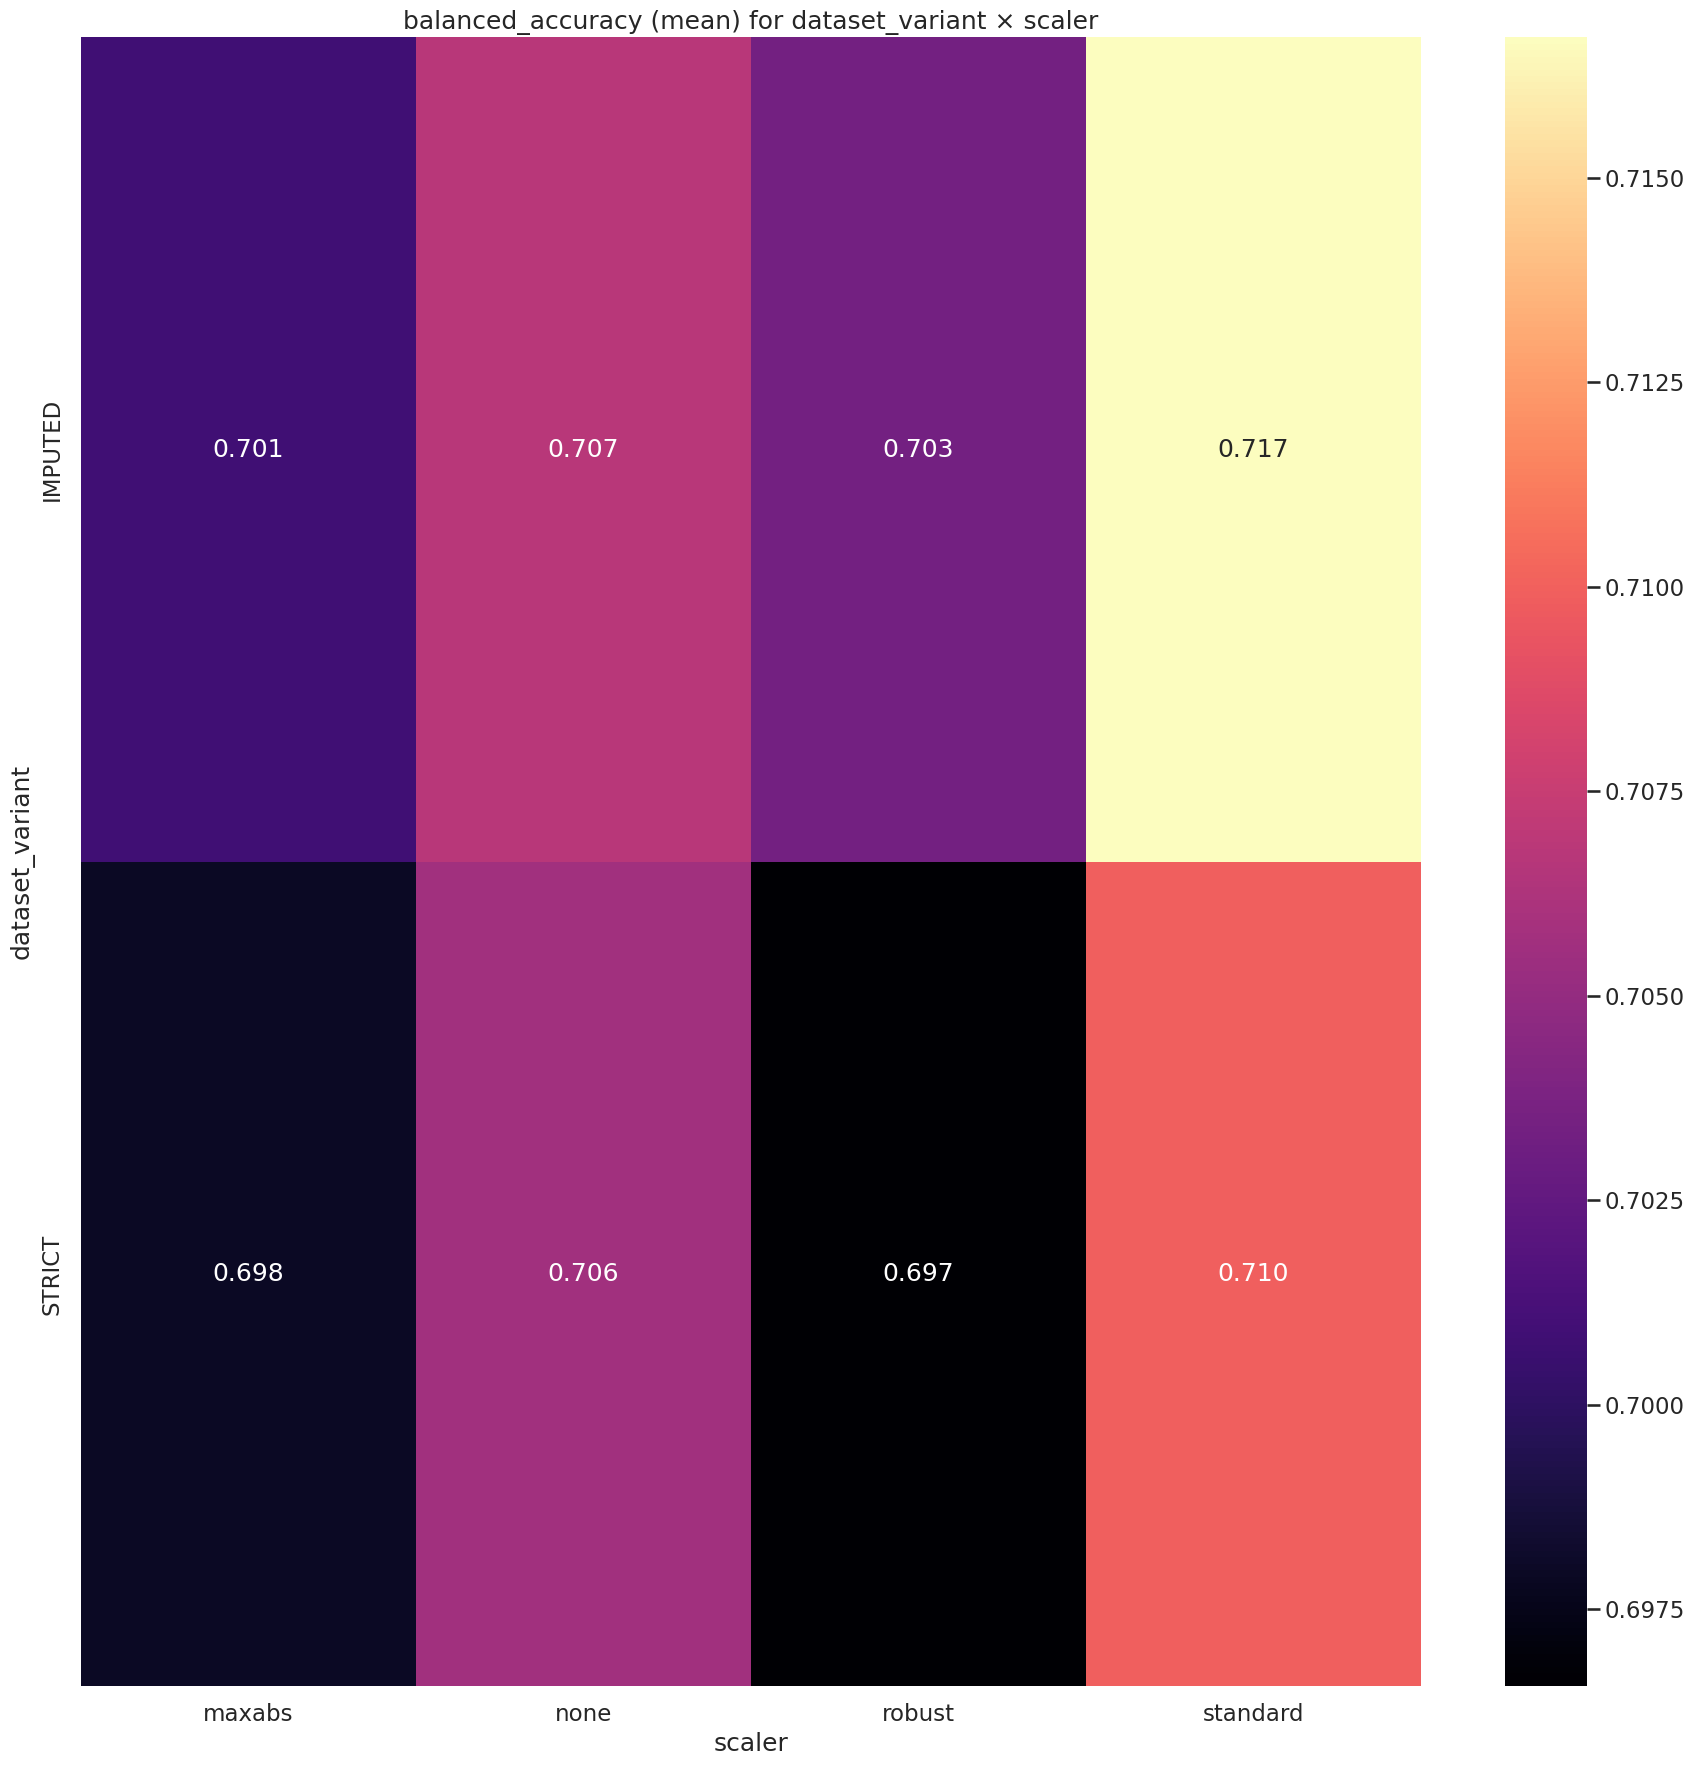

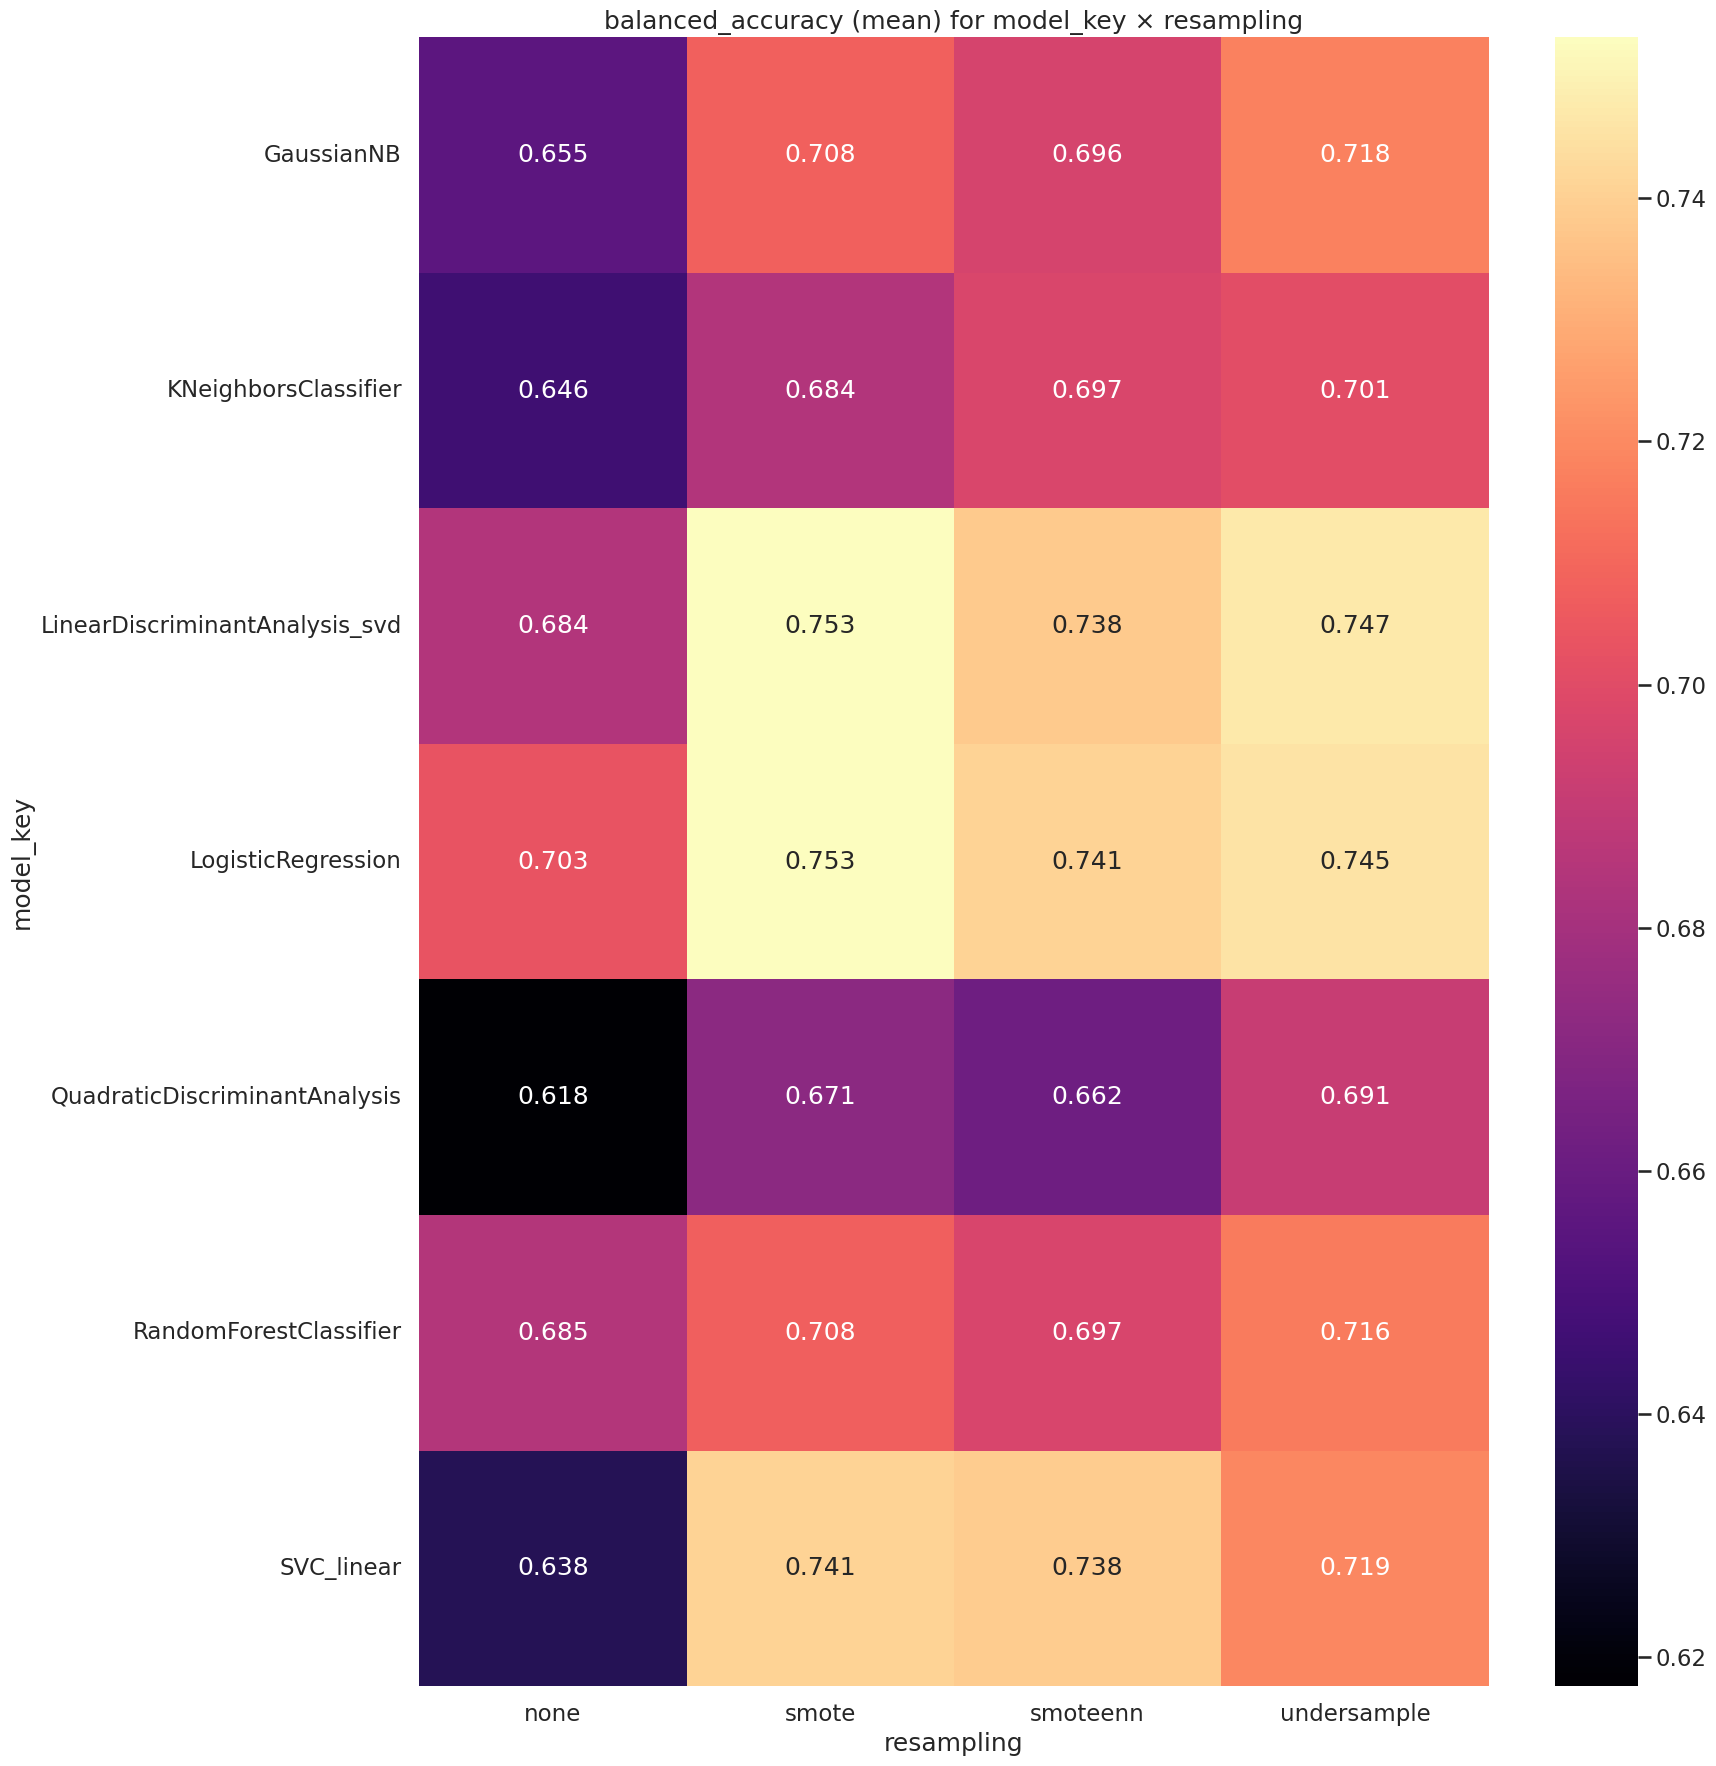

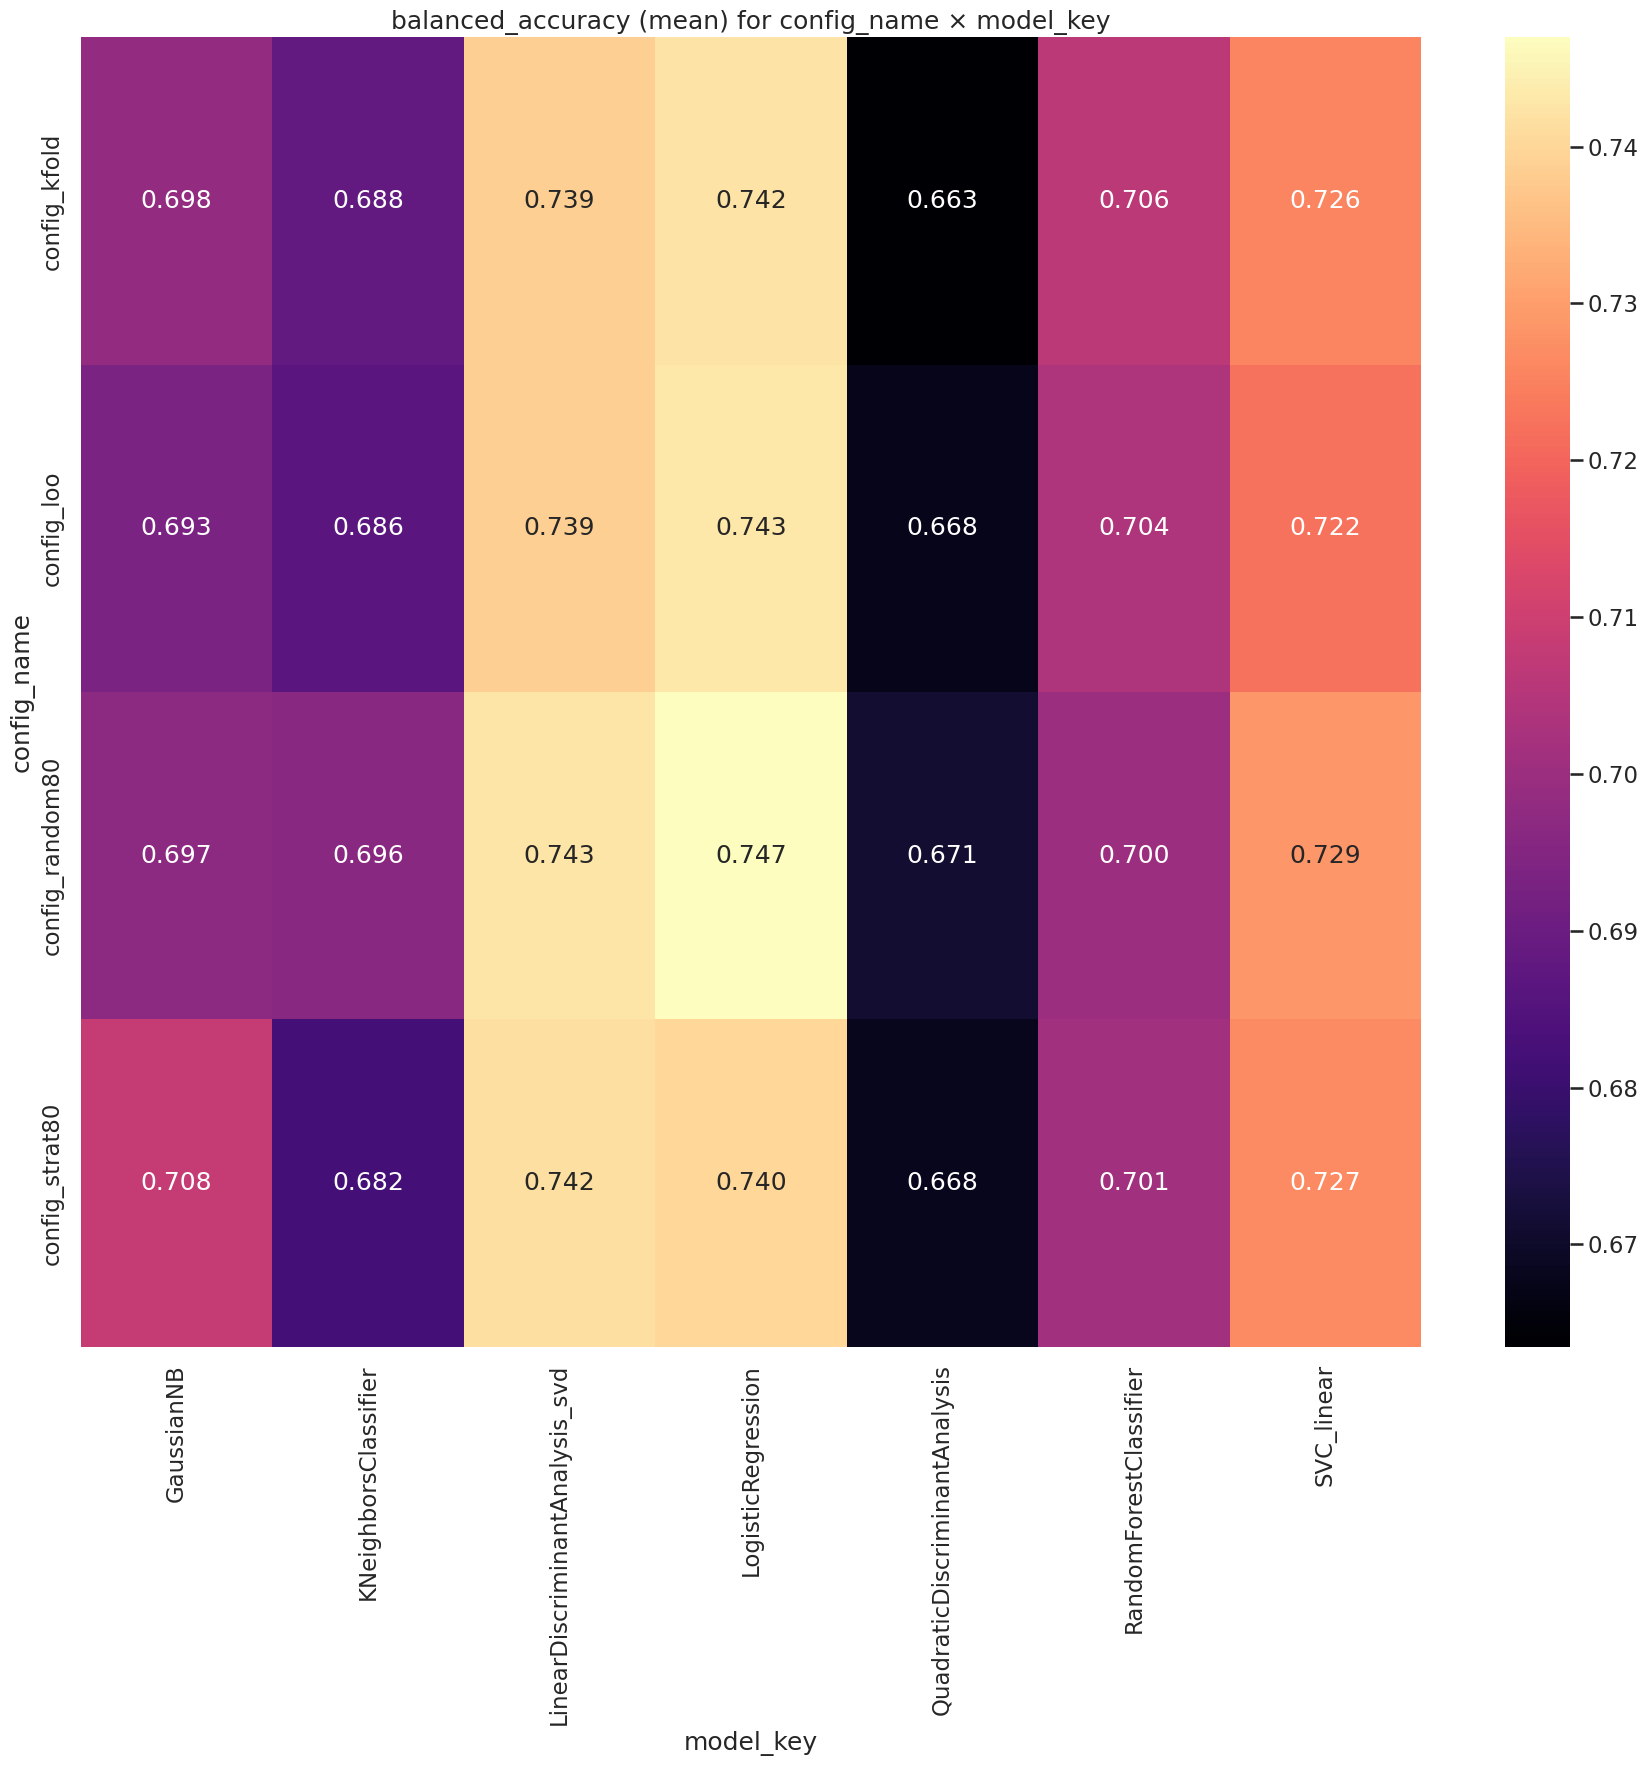

In [25]:
# A second interaction view using balanced accuracy as a complementary metric
for row_factor, col_factor in [("dataset_variant", "scaler"), ("model_key", "resampling"), ("config_name", "model_key")]:
    if row_factor in df.columns and col_factor in df.columns and "balanced_accuracy" in df.columns:
        fig, pivot = interaction_heatmap(
            df,
            row_factor=row_factor,
            col_factor=col_factor,
            metric="balanced_accuracy",
            aggfunc="mean",
            figsize=(max(18, 1.2 * df[row_factor].nunique()), max(18, 0.8 * df[col_factor].nunique())),
            cmap="magma",
        )
        interaction_tables[f"{row_factor}__{col_factor}__balanced_accuracy"] = pivot
        save_figure(fig, f"heatmap_{row_factor}__{col_factor}__balanced_accuracy_mean.png")
        plt.show()

## Best combinations under fair-comparison metrics

At this stage, the goal is to identify the strongest combinations under metrics that remain comparable across all validation strategies, including LOO. The ranking below prioritizes MCC and balanced accuracy, while keeping track of stability across seeds.

In [20]:
if results_config_level is not None:
    config_df = results_config_level.copy()
else:
    group_cols = [c for c in [
        "dataset_variant", "config_name", "val_strategy", "threshold",
        "model_key", "model_class", "model_params", "imputer",
        "scaler", "pca", "pca_params", "resampling", "resampling_params"
    ] if c in df.columns]
    agg_map = {
        "seed": "nunique",
        "accuracy": ["mean", "std"],
        "precision": ["mean", "std"],
        "recall": ["mean", "std"],
        "f1": ["mean", "std"],
        "balanced_accuracy": ["mean", "std"],
        "mcc": ["mean", "std"],
    }
    config_df = df.groupby(group_cols).agg(agg_map)
    config_df.columns = ["_".join([c for c in col if c]).rstrip("_") for col in config_df.columns]
    config_df = config_df.reset_index().rename(columns={"seed_nunique": "n_seed_runs"})

for required_col in ["accuracy_mean", "precision_mean", "recall_mean", "f1_mean", "balanced_accuracy_mean", "mcc_mean"]:
    if required_col not in config_df.columns and required_col.replace("_mean", "") in df.columns:
        pass

fair_metric_cols = [c for c in [
    "accuracy_mean", "precision_mean", "recall_mean", "f1_mean", "balanced_accuracy_mean", "mcc_mean"
] if c in config_df.columns]

config_rank = config_df.copy()

for metric_col in fair_metric_cols:
    rank_col = f"rank_{metric_col.replace('_mean', '')}"
    config_rank[rank_col] = config_rank[metric_col].rank(ascending=False, method="dense")

rank_cols = [c for c in config_rank.columns if c.startswith("rank_")]
if rank_cols:
    config_rank["fair_composite_rank_mean"] = config_rank[rank_cols].mean(axis=1)
    config_rank = config_rank.sort_values(["fair_composite_rank_mean", "mcc_mean"], ascending=[True, False])

top_columns = [c for c in [
    "dataset_variant", "config_name", "val_strategy", "model_key", "model_class",
    "imputer", "scaler", "pca", "resampling", "n_seed_runs",
    "accuracy_mean", "accuracy_std",
    "precision_mean", "precision_std",
    "recall_mean", "recall_std",
    "f1_mean", "f1_std",
    "balanced_accuracy_mean", "balanced_accuracy_std",
    "mcc_mean", "mcc_std",
    "fair_composite_rank_mean"
] if c in config_rank.columns]

top_configs_fair = config_rank[top_columns].head(30)
top_configs_fair

,dataset_variant,config_name,val_strategy,model_key,model_class,imputer,scaler,pca,resampling,n_seed_runs,accuracy_mean,accuracy_std,precision_mean,precision_std,recall_mean,recall_std,f1_mean,f1_std,balanced_accuracy_mean,balanced_accuracy_std,mcc_mean,mcc_std,fair_composite_rank_mean
94524,IMPUTED,config_strat80,stratified_split_80_20,SVC_linear,SVC,median,standard,on,smoteenn,10,0.812500,0.094327,0.636663,0.155001,0.911111,0.136586,0.739369,0.123893,0.842512,0.087564,0.639318,0.175664,424.333333
94799,IMPUTED,config_strat80,stratified_split_80_20,SVC_linear,SVC,none,standard,on,smoteenn,10,0.812500,0.094327,0.636663,0.155001,0.911111,0.136586,0.739369,0.123893,0.842512,0.087564,0.639318,0.175664,424.333333
93274,IMPUTED,config_strat80,stratified_split_80_20,SVC_linear,SVC,median,robust,off,smote,10,0.831250,0.072469,0.679529,0.144761,0.822222,0.175291,0.731832,0.121853,0.828502,0.088163,0.630906,0.168971,507.500000
93549,IMPUTED,config_strat80,stratified_split_80_20,SVC_linear,SVC,none,robust,off,smote,10,0.831250,0.072469,0.679529,0.144761,0.822222,0.175291,0.731832,0.121853,0.828502,0.088163,0.630906,0.168971,507.500000
94523,IMPUTED,config_strat80,stratified_split_80_20,SVC_linear,SVC,median,standard,on,smoteenn,10,0.803125,0.104219,0.624127,0.164876,0.900000,0.142965,0.727938,0.134661,0.832609,0.104670,0.618587,0.206039,572.166667
94798,IMPUTED,config_strat80,stratified_split_80_20,SVC_linear,SVC,none,standard,on,smoteenn,10,0.803125,0.104219,0.624127,0.164876,0.900000,0.142965,0.727938,0.134661,0.832609,0.104670,0.618587,0.206039,572.166667
93307,IMPUTED,config_strat80,stratified_split_80_20,SVC_linear,SVC,median,robust,on,smote,10,0.828125,0.071032,0.669708,0.132936,0.811111,0.166048,0.724985,0.122328,0.822947,0.088626,0.617686,0.169193,611.833333
93351,IMPUTED,config_strat80,stratified_split_80_20,SVC_linear,SVC,median,robust,on,smote,10,0.828125,0.071032,0.669708,0.132936,0.811111,0.166048,0.724985,0.122328,0.822947,0.088626,0.617686,0.169193,611.833333
93582,IMPUTED,config_strat80,stratified_split_80_20,SVC_linear,SVC,none,robust,on,smote,10,0.828125,0.071032,0.669708,0.132936,0.811111,0.166048,0.724985,0.122328,0.822947,0.088626,0.617686,0.169193,611.833333
93626,IMPUTED,config_strat80,stratified_split_80_20,SVC_linear,SVC,none,robust,on,smote,10,0.828125,0.071032,0.669708,0.132936,0.811111,0.166048,0.724985,0.122328,0.822947,0.088626,0.617686,0.169193,611.833333


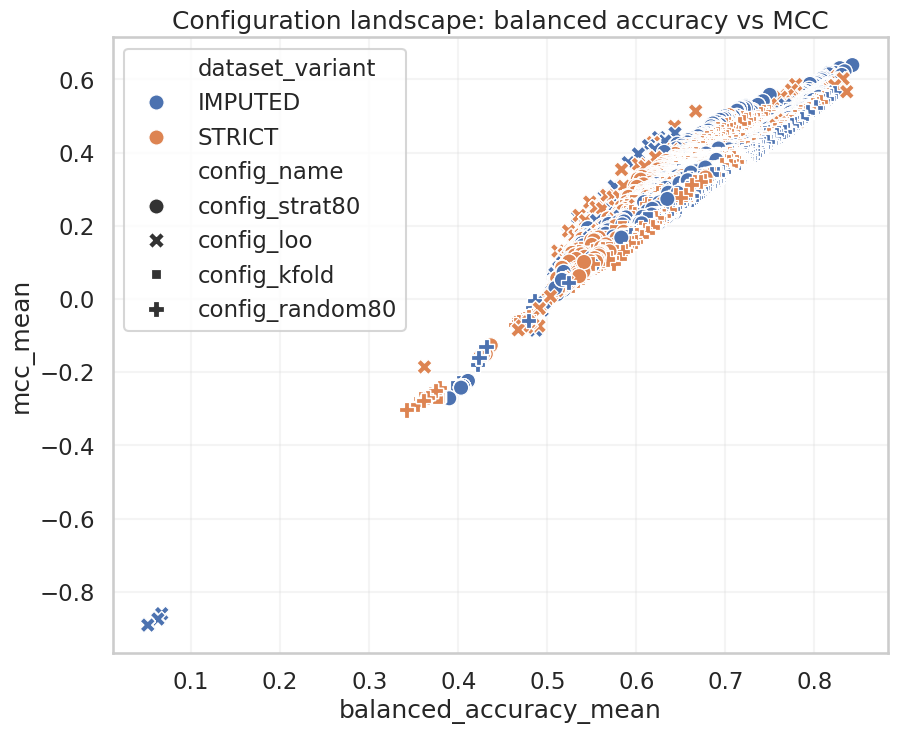

In [21]:
if "mcc_mean" in config_rank.columns and "balanced_accuracy_mean" in config_rank.columns:
    fig, ax = plt.subplots(figsize=(10, 8))
    plot_df = config_rank.copy()
    sns.scatterplot(
        data=plot_df,
        x="balanced_accuracy_mean",
        y="mcc_mean",
        hue="dataset_variant" if "dataset_variant" in plot_df.columns else None,
        style="config_name" if "config_name" in plot_df.columns else None,
        s=120,
        ax=ax,
    )
    ax.set_title("Configuration landscape: balanced accuracy vs MCC")
    ax.grid(alpha=0.2)
    save_figure(fig, "config_landscape_balanced_accuracy_vs_mcc.png")
    plt.show()

## Restricted probabilistic analysis (non-LOO only)

The following block is optional and intended only for validation strategies where probability-based metrics were computed and are comparable. This is not used for the fair cross-strategy comparison that includes LOO.

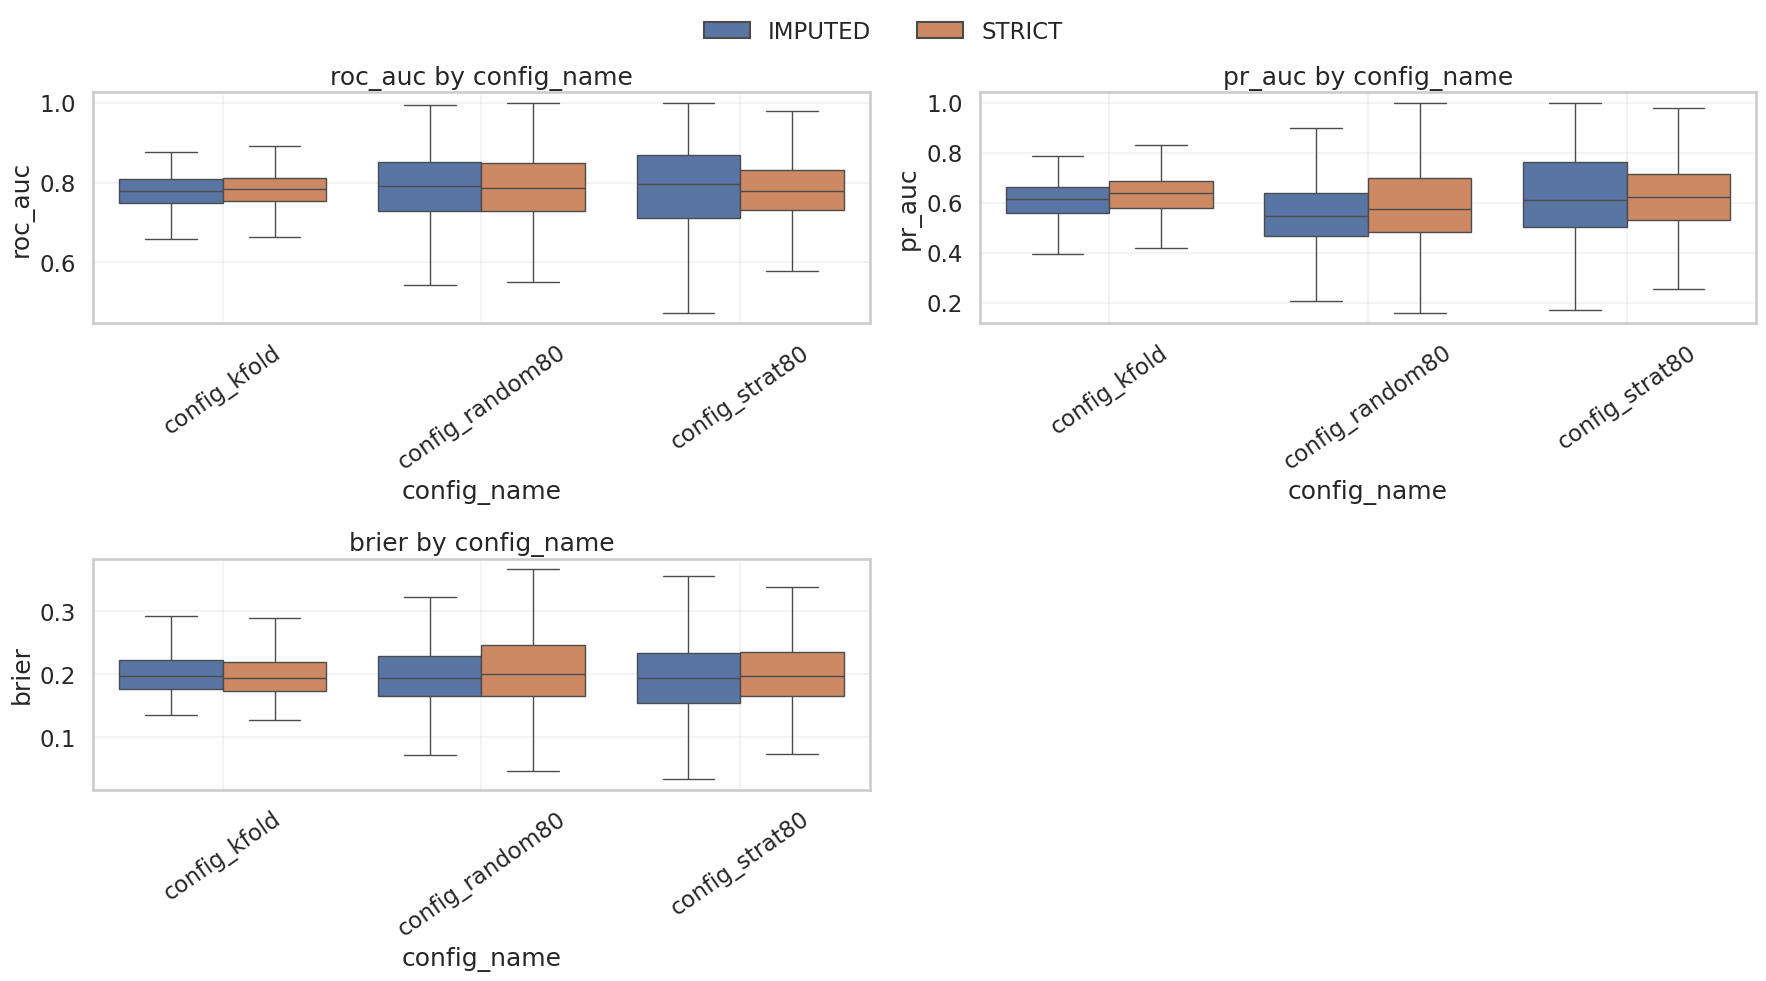

In [22]:
if {"config_name", "roc_auc", "pr_auc", "brier"}.issubset(df.columns):
    nonloo_df = df.loc[df["config_name"] != "config_loo"].copy()
    if not nonloo_df.empty:
        fig = plot_factor_boxplots(
            nonloo_df,
            factor="config_name",
            metrics=[m for m in ["roc_auc", "pr_auc", "brier"] if m in nonloo_df.columns],
            hue="dataset_variant" if "dataset_variant" in nonloo_df.columns else None,
            figsize=(18, 10),
        )
        save_figure(fig, "nonloo_probabilistic_metrics_by_config.png")
        plt.show()

## Exports

The tables generated in this notebook are saved so they can be reused in later notebooks, manuscript tables, and figure generation pipelines.

In [23]:
# Export factor summaries
for factor, summary in factor_summaries.items():
    summary.to_csv(ANALYSIS_DIR / f"factor_summary__{factor}.csv", index=False)

# Export ranking tables
for factor, summary in ranking_tables.items():
    summary.to_csv(ANALYSIS_DIR / f"factor_ranking__{factor}.csv", index=False)

# Export interaction tables
for key, table in interaction_tables.items():
    safe_key = key.replace("/", "_")
    table.to_csv(ANALYSIS_DIR / f"interaction__{safe_key}.csv")

# Export top configurations
top_configs_fair.to_csv(ANALYSIS_DIR / "top_configs_fair_comparison.csv", index=False)

print("Saved factor summaries, rankings, interactions, and top fair-comparison configs.")
print("Analysis directory:", ANALYSIS_DIR)
print("Figures directory:", FIGURES_DIR)
sorted(FIGURES_DIR.glob("*.png"))

Saved factor summaries, rankings, interactions, and top fair-comparison configs.
Analysis directory: /home/david/Desktop/colabs/serra_ramon/hypercholesterolemia_classifiers/notebooks/modelling/analysis_tables
Figures directory: /home/david/Desktop/colabs/serra_ramon/hypercholesterolemia_classifiers/notebooks/modelling/analysis_figures/02_factor_effects


[PosixPath('/home/david/Desktop/colabs/serra_ramon/hypercholesterolemia_classifiers/notebooks/modelling/analysis_figures/02_factor_effects/config_landscape_balanced_accuracy_vs_mcc.png'),
 PosixPath('/home/david/Desktop/colabs/serra_ramon/hypercholesterolemia_classifiers/notebooks/modelling/analysis_figures/02_factor_effects/config_name_effect_boxplots.png'),
 PosixPath('/home/david/Desktop/colabs/serra_ramon/hypercholesterolemia_classifiers/notebooks/modelling/analysis_figures/02_factor_effects/dataset_variant_effect_boxplots.png'),
 PosixPath('/home/david/Desktop/colabs/serra_ramon/hypercholesterolemia_classifiers/notebooks/modelling/analysis_figures/02_factor_effects/heatmap_config_name__model_key__balanced_accuracy_mean.png'),
 PosixPath('/home/david/Desktop/colabs/serra_ramon/hypercholesterolemia_classifiers/notebooks/modelling/analysis_figures/02_factor_effects/heatmap_config_name__model_key__mcc_mean.png'),
 PosixPath('/home/david/Desktop/colabs/serra_ramon/hypercholesterolemia_